# 21 — Energy function: one concrete user, worked term by term

Standalone from `20_energy_function_5k.ipynb` on purpose. Notebook 20 reports **batch statistics** (real vs. shuffled energy, averaged over all 5,000 users) — this notebook is the single-user version, so the energy function's actual output can be inspected as one concrete number rather than an aggregate. Same demo user (3268) used throughout notebooks 17/18/19, so this is directly comparable to earlier demos.

No retraining anywhere here — loads `e₊`'s already-trained weights (`13b_encodingB_personality_training.ipynb`) and computes $E(v,h) = -v^\top W h - b_h^\top h$ (no visible bias term, matching the actual `train_rbm` implementation).

## Part 0 — Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent

data_dir = root / "data"
proc = root / "data" / "processed"
out_dir = root / "outputs"
out_dir.mkdir(parents=True, exist_ok=True)
K = 10
DEMO_USER_ID = 3268


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-np.clip(x, -60.0, 60.0)))


W_plus = np.load(proc / "rbmB1_weights_5k.npy")
bh_plus = np.load(proc / "rbmB1_bias_hidden_5k.npy")
channelB1 = np.load(proc / "channelB1_softmax.npy", mmap_mode="r")
mask = np.load(proc / "mask.npy", mmap_mode="r")
cohort_user_ids = np.load(proc / "cohort_user_ids.npy").astype(int)
movie_vocab = np.load(proc / "movie_vocab.npy").astype(int)
n_movies = len(movie_vocab)
n_hidden = bh_plus.shape[0]
user_to_row = {int(uid): i for i, uid in enumerate(cohort_user_ids)}

print(f"e+ : W {W_plus.shape}  bh {bh_plus.shape}  (frozen, trained in 13b)")
print(f"Demo user: {DEMO_USER_ID}")

e+ : W (131290, 128)  bh (128,)  (frozen, trained in 13b)
Demo user: 3268


## Part 1 — Definitions: energy function and this user's rating distribution

### 2.1.1 Energy function

$$E(v,h) = -\sum_{i,k} a_{i,k}\, v_{i,k} \;-\; \sum_j b_j\, h_j \;-\; \sum_{i,k,j} v_{i,k}\, W_{(i,k),j}\, h_j$$

| Symbol | Meaning |
|---|---|
| $v_{i,k} \in \{0,1\}$ | Visible unit, one-hot -- movie $i$ ($i=1,\dots,13129$) at rating level $k$ ($k=1,\dots,10$, corresponding to 0.5-5.0). For a rated movie, exactly one $k$ is 1; unrated movies are all 0 (masked). |
| $h_j \in \{0,1\}$ | Hidden unit, binary, $j=1,\dots,128$. |
| $a_{i,k}$ | Visible bias -- baseline tendency for movie $i$ to receive rating level $k$, independent of any hidden unit. **Not present in the actual trained `e₊`** (13b never defines this parameter) -- included here for the full/formal definition. |
| $b_j$ | Hidden bias -- baseline tendency for hidden unit $j$ to activate. |
| $W_{(i,k),j}$ | Weight connecting visible unit $(i,k)$ to hidden unit $j$. |

### This user's rating distribution

Demo user 3268's real train-set ratings (`v` before any RBM computation touches it) -- shown before running anything through the model, since $v$ is the model's raw input, not a derived quantity.

In [2]:
from collections import Counter

RATING_LEVELS = np.array([0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0])

cols_demo = np.where(np.asarray(mask[demo_row]) == 1)[0] if "demo_row" in dir() else np.where(np.asarray(mask[user_to_row[DEMO_USER_ID]]) == 1)[0]
demo_row = user_to_row[DEMO_USER_ID]
block_demo = np.asarray(channelB1[demo_row, cols_demo, :])
ks_demo = block_demo.argmax(axis=1)
ratings_demo = RATING_LEVELS[ks_demo]

print(f"User {DEMO_USER_ID}: {len(cols_demo)} rated movies in train set")
counts_demo = Counter(ratings_demo)
for r in RATING_LEVELS:
    c = counts_demo.get(r, 0)
    print(f"  {r:.1f} : {c:4d} ({c/len(ratings_demo)*100:5.1f}%)")
print(f"\nmean={ratings_demo.mean():.4f}  std={ratings_demo.std():.4f}")

User 3268: 696 rated movies in train set
  0.5 :    3 (  0.4%)
  1.0 :    1 (  0.1%)
  1.5 :    8 (  1.1%)
  2.0 :   12 (  1.7%)
  2.5 :   36 (  5.2%)
  3.0 :   99 ( 14.2%)
  3.5 :  185 ( 26.6%)
  4.0 :  256 ( 36.8%)
  4.5 :   78 ( 11.2%)
  5.0 :   18 (  2.6%)

mean=3.6466  std=0.6786


#### Same distribution, as a chart

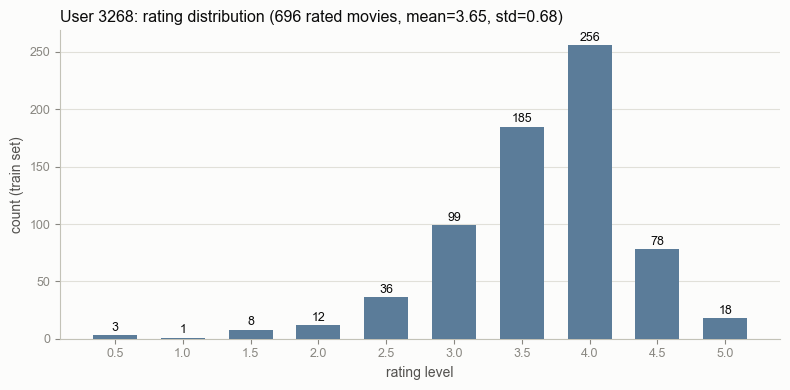

In [3]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
BAR_COLOR = "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

vals = [counts_demo.get(r, 0) for r in RATING_LEVELS]

fig, ax = plt.subplots(figsize=(8, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar([f"{r:.1f}" for r in RATING_LEVELS], vals, color=BAR_COLOR, width=0.65, zorder=3)
for i, v in enumerate(vals):
    ax.text(i, v + max(vals) * 0.015, f"{v}", ha="center", fontsize=9, color=INK_PRIMARY)
ax.set_xlabel("rating level", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("count (train set)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: rating distribution ({len(cols_demo)} rated movies, "
             f"mean={ratings_demo.mean():.2f}, std={ratings_demo.std():.2f})",
             color=INK_PRIMARY, fontsize=11.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_rating_distribution.png", dpi=150, facecolor=SURFACE)
plt.show()

### The visible layer, concretely: one-hot, 0/1, with real movies

$v_{i,k}$ is not abstract -- for a handful of user 3268's actual rated movies, this is exactly what the one-hot row looks like: 10 slots per movie, exactly one 1, rest 0.

In [4]:
movies_title_map = pd.read_csv(data_dir / "movie.csv").set_index("movieId")["title"].to_dict()

target_levels = [0.5, 2.0, 3.0, 3.5, 4.0, 5.0]
picked_idx = []
for tl in target_levels:
    idxs = np.where(ratings_demo == tl)[0]
    if len(idxs):
        picked_idx.append(idxs[0])

mids_demo = movie_vocab[cols_demo]
sample_titles = [movies_title_map.get(int(mids_demo[i]), "?") for i in picked_idx]
sample_onehot = block_demo[picked_idx]  # (n_sample, K)

print("Sample of this user's real one-hot rows (movie x rating-level):")
for t, row_oh, r in zip(sample_titles, sample_onehot, [ratings_demo[i] for i in picked_idx]):
    print(f"  {t[:40]:40s} rating={r:.1f}  onehot={row_oh.astype(int).tolist()}")

Sample of this user's real one-hot rows (movie x rating-level):
  Napoleon Dynamite (2004)                 rating=0.5  onehot=[1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
  Zoolander (2001)                         rating=2.0  onehot=[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
  Casper (1995)                            rating=3.0  onehot=[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Jumanji (1995)                           rating=3.5  onehot=[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]
  Toy Story (1995)                         rating=4.0  onehot=[0, 0, 0, 0, 0, 0, 0, 1, 0, 0]
  Léon: The Professional (a.k.a. The Profe rating=5.0  onehot=[0, 0, 0, 0, 0, 0, 0, 0, 0, 1]


#### Same rows, as a visual grid

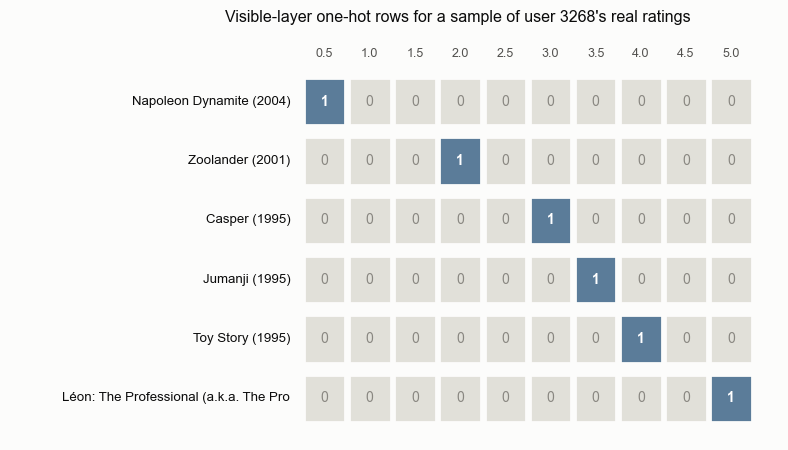

In [5]:
import matplotlib.pyplot as plt2

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_COLOR, ONE_COLOR = "#e1e0d9", "#5b7c99"
plt2.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

n_sample = len(sample_titles)
fig, ax = plt2.subplots(figsize=(8, 0.55 * n_sample + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for row_i, (t, row_oh) in enumerate(zip(sample_titles, sample_onehot)):
    for col_j in range(K):
        val = int(row_oh[col_j])
        color = ONE_COLOR if val == 1 else ZERO_COLOR
        ax.add_patch(plt2.Rectangle((col_j, n_sample - 1 - row_i), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
        txt_color = "white" if val == 1 else INK_MUTED
        ax.text(col_j + 0.46, n_sample - 1 - row_i + 0.4, str(val), ha="center", va="center", fontsize=10, color=txt_color, fontweight="bold" if val else "normal")
    ax.text(-0.3, n_sample - 1 - row_i + 0.4, t[:38], ha="right", va="center", fontsize=9.5, color=INK_PRIMARY)

for col_j, r in enumerate(RATING_LEVELS):
    ax.text(col_j + 0.46, n_sample + 0.15, f"{r:.1f}", ha="center", fontsize=9, color=INK_SECONDARY)

ax.set_xlim(-6.5, K + 0.5)
ax.set_ylim(-0.3, n_sample + 0.6)
ax.axis("off")
ax.set_title("Visible-layer one-hot rows for a sample of user 3268's real ratings", color=INK_PRIMARY, fontsize=11.5, loc="left", x=0.28)
plt2.tight_layout()
plt2.savefig(out_dir / "user3268_onehot_detail.png", dpi=150, facecolor=SURFACE)
plt2.show()

### Introducing `e₊`

The definition above (§2.1.1) is generic -- it applies to any RBM channel. Instantiating it for `e₊` specifically:

- $W \to$ `W1` (shape `131290 x 128`, trained in `13b_encodingB_personality_training.ipynb`)
- $b \to$ `bh1` (shape `128`)
- $a \to$ **not present** -- confirmed earlier by reading `train_rbm` in 13b: no visible-bias parameter is ever initialized, updated, or used in the reconstruction step. The trained `e₊` is the no-bias special case of the formula above ($a_{i,k}=0$ for all $i,k$).
- $v \to$ user 3268's real rating vector (the distribution just plotted)

**CD-1's starting point -- the positive phase**: given the real data $v$, compute $P(h_j=1\mid v) = \text{sigmoid}\big(\sum_{i,k} v_{i,k}W_{(i,k),j} + b_j\big)$. This is the first quantity computed in the whole CD-1 cycle -- everything else (reconstruction, negative phase) is downstream of this.

In [6]:
# Positive phase: P(h=1 | v_data) = sigmoid(v_data @ W1 + bh1), using e+'s real trained weights
v_demo = np.asarray(channelB1[demo_row]).reshape(-1).astype(np.float64)
h_prob_positive = sigmoid(v_demo @ W_plus + bh_plus)

print(f"v (user {DEMO_USER_ID}'s real ratings): {int((v_demo != 0).sum())} nonzero entries")
print(f"h_prob (positive phase): shape={h_prob_positive.shape}")
print(f"  min={h_prob_positive.min():.4f}  max={h_prob_positive.max():.4f}  mean={h_prob_positive.mean():.4f}")
print(f"  first 10 values: {np.round(h_prob_positive[:10], 3)}")

v (user 3268's real ratings): 696 nonzero entries
h_prob (positive phase): shape=(128,)
  min=0.1544  max=1.0000  mean=0.8425
  first 10 values: [0.994 0.77  0.999 1.    1.    0.797 1.    0.37  0.154 0.998]


### 2.1.2 Hammersley–Clifford → Gibbs distribution

The RBM's graph is **bipartite**: visible nodes $v_{i,k}$ and hidden nodes $h_j$, edges only between the two sides -- no $v$-$v$ edges, no $h$-$h$ edges. That specific structure gives the key conditional-independence (Markov) property: given $h$, all $v_{i,k}$ are independent of each other; given $v$, all $h_j$ are independent of each other. (This is exactly what makes Step 1a's computation a single vectorized `sigmoid` call over all 128 units at once, instead of 128 separate conditional computations -- each $h_j$ only depends on $v$, not on the other $h_{j'}$.)

**Hammersley–Clifford theorem**: for a Markov random field satisfying positivity (every configuration has nonzero probability, true here since sigmoid outputs are always strictly between 0 and 1), the joint distribution factorizes over the graph's *cliques*:

$$P(v,h) = \frac{1}{Z}\exp(-E(v,h))$$

For this bipartite graph, the only cliques are single nodes and single edges (no $v$-$v$ or $h$-$h$ edges means no larger clique exists). That is exactly why $E(v,h)$ from §2.1.1 has the form it does -- unary terms ($a_{i,k}v_{i,k}$, $b_jh_j$) for the size-1 cliques, plus pairwise terms ($v_{i,k}W_{(i,k),j}h_j$) for the size-2 cliques, and nothing higher-order. The energy function's shape is not an arbitrary choice -- it's what Hammersley–Clifford forces given this graph topology.

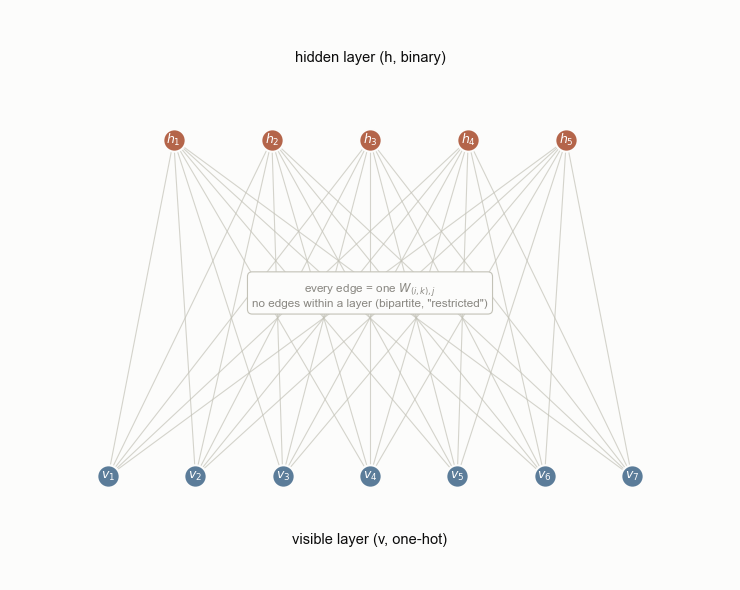

In [7]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
V_COLOR, H_COLOR, EDGE_COLOR = "#5b7c99", "#b4654a", "#c3c2b7"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

n_v_show, n_h_show = 7, 5  # illustrative subset -- real graph is 131290 x 128, unreadable at full scale

fig, ax = plt.subplots(figsize=(7.5, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

# transposed: hidden layer on TOP, visible layer on BOTTOM
v_x = np.linspace(0.1, 0.9, n_v_show)
h_x = np.linspace(0.2, 0.8, n_h_show)
v_y, h_y = 0.15, 0.8

for xv in v_x:
    for xh in h_x:
        ax.plot([xv, xh], [v_y, h_y], color=EDGE_COLOR, linewidth=0.8, zorder=1, alpha=0.7)

ax.scatter(h_x, [h_y] * n_h_show, s=260, color=H_COLOR, zorder=3, edgecolors=SURFACE, linewidths=1.5)
ax.scatter(v_x, [v_y] * n_v_show, s=260, color=V_COLOR, zorder=3, edgecolors=SURFACE, linewidths=1.5)

for j, xh in enumerate(h_x):
    ax.text(xh, h_y, f"$h_{{{j+1}}}$", ha="center", va="center", fontsize=9, color="white", zorder=4)
for i, xv in enumerate(v_x):
    ax.text(xv, v_y, f"$v_{{{i+1}}}$", ha="center", va="center", fontsize=9, color="white", zorder=4)

ax.text(0.5, 0.95, "hidden layer (h, binary)", ha="center", fontsize=10.5, color=INK_PRIMARY)
ax.text(0.5, 0.02, "visible layer (v, one-hot)", ha="center", fontsize=10.5, color=INK_PRIMARY)
ax.text(0.5, 0.5, "every edge = one $W_{(i,k),j}$\nno edges within a layer (bipartite, \"restricted\")",
        ha="center", va="center", fontsize=8.5, color=INK_MUTED,
        bbox=dict(boxstyle="round,pad=0.4", facecolor=SURFACE, edgecolor=EDGE_COLOR, linewidth=0.8))

ax.set_xlim(-0.05, 1.05)
ax.set_ylim(-0.05, 1.05)
ax.axis("off")
plt.tight_layout()
plt.savefig(out_dir / "rbm_bipartite_graph.png", dpi=150, facecolor=SURFACE)
plt.show()

## CD-1, the four-step dance

#### Step 1 — Positive phase: $v^0 \to \sigma \to$ Bernoulli $\to h^0$

**Derivation (the sigmoid is not assumed -- it falls out of the energy function):**

Start from the Gibbs distribution, $P(v,h) = \frac{1}{Z}\exp(-E(v,h))$. Isolate the terms of $E(v,h)$ that involve one specific hidden unit $h_j$:

$$E(v,h) = C(v, h_{-j}) \;-\; h_j\underbrace{\Big(b_j + \sum_{i,k} v_{i,k}\,W_{(i,k),j}\Big)}_{=:\,I_j}$$

where $C(v,h_{-j})$ collects every term that does *not* depend on $h_j$ (the visible-bias terms and all other hidden units), and $I_j$ is the total input to unit $j$. Since $h_j\in\{0,1\}$, take the ratio of the two possible energies:

$$\frac{P(h_j{=}1\mid v)}{P(h_j{=}0\mid v)} = \frac{\exp(-E(v,h_j{=}1))}{\exp(-E(v,h_j{=}0))} = \frac{\exp(-(C-I_j))}{\exp(-C)} = \exp(I_j)$$

Combined with $P(h_j{=}1\mid v)+P(h_j{=}0\mid v)=1$:

$$P(h_j{=}1\mid v) = \frac{\exp(I_j)}{1+\exp(I_j)} = \frac{1}{1+\exp(-I_j)} = \sigma(I_j)$$

**Masking**: the sum $\sum_{i,k}$ only has nonzero contributions from movies $i$ this user actually rated in train (`mask[demo_row]==1`) -- for every unrated movie, $v_{i,k}=0$ for all $k=1,\dots,10$ by construction (nothing is one-hot there), so those positions contribute $0$ to $I_j$ automatically. Masking isn't a separate step here; it's structurally already enforced by how $v^0$ itself was built.

**Sampling**: $h_j^0 \sim \text{Bernoulli}\big(\sigma(I_j)\big)$.

##### Masking, verified (not just claimed)

In [8]:
v0 = np.asarray(channelB1[demo_row]).reshape(-1).astype(np.float64)
n_rated_check = int(np.asarray(mask[demo_row]).sum())

# confirm masking is structural: unrated movies contribute exactly 0, not just "should"
rated_cols = np.where(np.asarray(mask[demo_row]) == 1)[0]
unrated_cols = np.where(np.asarray(mask[demo_row]) == 0)[0]
v0_reshaped = v0.reshape(n_movies, K)
print(f"v0: {int((v0 != 0).sum())} nonzero entries total")
print(f"  at RATED positions ({len(rated_cols)} movies): {int(v0_reshaped[rated_cols].sum())} ones (should = {len(rated_cols)}, one per movie)")
print(f"  at UNRATED positions ({len(unrated_cols)} movies): {int(v0_reshaped[unrated_cols].sum())} ones (should = 0)")


v0: 696 nonzero entries total
  at RATED positions (696 movies): 696 ones (should = 696, one per movie)
  at UNRATED positions (12433 movies): 0 ones (should = 0)


##### Sigmoid: $I_j$ and $h_{\text{prob}}^0=\sigma(I_j)$

*How the probability is **computed**: a deterministic map from the energy function. The same $v^0$ always gives the same $h_{\text{prob}}^0$.*


I_j:       min=-1.7008  max=10.7256  mean=4.3634
h_prob_0 = sigma(I_j):  min=0.1544  max=1.0000  mean=0.8425
first 10 values: [0.994 0.77  0.999 1.    1.    0.797 1.    0.37  0.154 0.998]


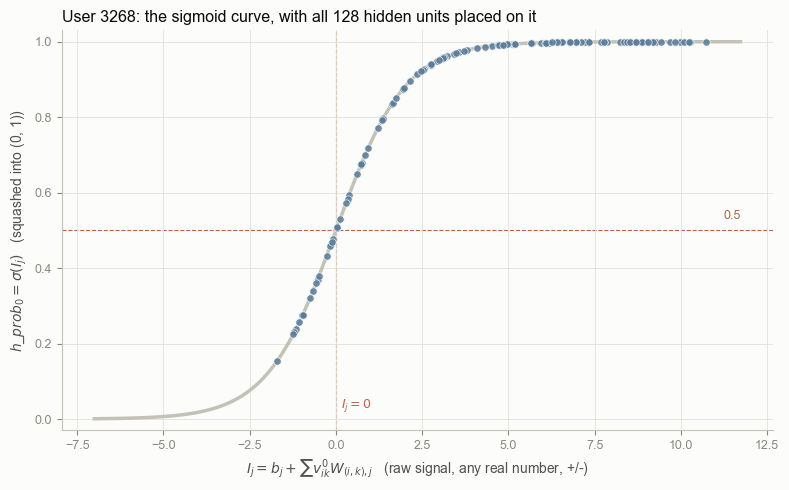

In [9]:
# sigmoid: I_j = b_j + sum v0_ik W_ikj,  h_prob_0 = sigma(I_j)
I_j = v0 @ W_plus + bh_plus
h_prob_0 = sigmoid(I_j)
print(f"I_j:       min={I_j.min():.4f}  max={I_j.max():.4f}  mean={I_j.mean():.4f}")
print(f"h_prob_0 = sigma(I_j):  min={h_prob_0.min():.4f}  max={h_prob_0.max():.4f}  mean={h_prob_0.mean():.4f}")
print(f"first 10 values: {np.round(h_prob_0[:10], 3)}")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR, REF_COLOR = "#c3c2b7", "#5b7c99", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# the sigmoid S-curve itself: this is the map that turns any real number (positive or negative) into (0, 1)
x_curve = np.linspace(min(I_j.min(), -6) - 1, max(I_j.max(), 6) + 1, 400)
y_curve = sigmoid(x_curve)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
ax.scatter(I_j, h_prob_0, color=DOT_COLOR, s=28, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.axhline(0.5, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.text(x_curve.max(), 0.53, "0.5", color=REF_COLOR, fontsize=9, ha="right")
ax.text(0.15, 0.03, "$I_j=0$", color=REF_COLOR, fontsize=9)

ax.set_xlabel(r"$I_j = b_j + \sum v^0_{ik} W_{(i,k),j}$   (raw signal, any real number, +/-)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob_0 = \sigma(I_j)$   (squashed into (0, 1))", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: the sigmoid curve, with all {n_hidden} hidden units placed on it", color=INK_PRIMARY, fontsize=11.5, loc="left")
ax.set_ylim(-0.03, 1.03)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step1_sigmoid.png", dpi=150, facecolor=SURFACE)
plt.show()


##### Bernoulli sample: $h^0$

*How the probability is **used**: a stochastic draw. The same $h_{\text{prob}}^0$ can give a different $h^0$ each time, but repeated draws converge back to $h_{\text{prob}}^0$.*


h0: 104 / 128 units sampled ON
which units: [0, 1, 2, 3, 4, 6, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19, 20, 21, 22, 23, 25, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 40, 41, 42, 43, 44, 45, 46, 47, 48, 51, 52, 53, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 80, 81, 82, 84, 85, 86, 88, 89, 90, 91, 92, 93, 95, 96, 100, 101, 103, 104, 105, 106, 107, 108, 109, 111, 113, 114, 115, 116, 117, 119, 120, 121, 123, 124, 125, 126, 127]


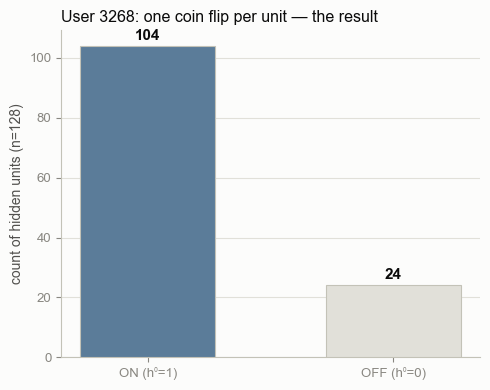

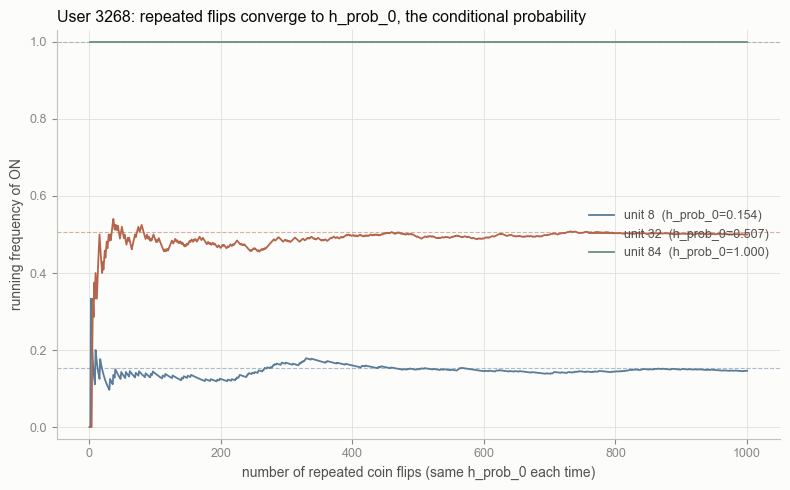

In [10]:
# Bernoulli sample: h0 ~ Bernoulli(h_prob_0)
rng_cd1 = np.random.default_rng(0)
h0 = (rng_cd1.random(h_prob_0.shape) < h_prob_0).astype(np.float64)
print(f"h0: {int(h0.sum())} / {n_hidden} units sampled ON")
print(f"which units: {np.where(h0 == 1)[0].tolist()}")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
ON_COLOR, OFF_COLOR = "#5b7c99", "#e1e0d9"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# ---- Chart A: one coin flip per unit -- the result distribution (ON vs OFF, this one draw) ----
n_on, n_off = int(h0.sum()), int(n_hidden - h0.sum())
fig, ax = plt.subplots(figsize=(5, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(["ON (h⁰=1)", "OFF (h⁰=0)"], [n_on, n_off], color=[ON_COLOR, OFF_COLOR], width=0.55, zorder=3, edgecolor=BASELINE, linewidth=0.8)
for b, v in zip(bars, [n_on, n_off]):
    ax.text(b.get_x() + b.get_width() / 2, v + max(n_on, n_off) * 0.02, f"{v}", ha="center", fontsize=11, color=INK_PRIMARY, fontweight="bold")
ax.set_ylabel(f"count of hidden units (n={n_hidden})", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: one coin flip per unit — the result", color=INK_PRIMARY, fontsize=11.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9.5)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step1_bernoulli_result.png", dpi=150, facecolor=SURFACE)
plt.show()

# ---- Chart B: repeat the SAME coin (same h_prob_0) many times -- frequency converges to the conditional probability ----
rep_idx = [int(np.argmin(h_prob_0)), int(np.argmin(np.abs(h_prob_0 - 0.5))), int(np.argmax(h_prob_0))]
n_flips = 1000
rng_conv = np.random.default_rng(1)
palette = ["#5b7c99", "#b4654a", "#6b9080"]

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
for c, j in enumerate(rep_idx):
    draws = (rng_conv.random(n_flips) < h_prob_0[j]).astype(np.float64)
    running_freq = np.cumsum(draws) / np.arange(1, n_flips + 1)
    ax.plot(np.arange(1, n_flips + 1), running_freq, color=palette[c], linewidth=1.3, zorder=3,
            label=f"unit {j}  (h_prob_0={h_prob_0[j]:.3f})")
    ax.axhline(h_prob_0[j], color=palette[c], linewidth=0.8, linestyle="--", alpha=0.5, zorder=2)

ax.set_xlabel("number of repeated coin flips (same h_prob_0 each time)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("running frequency of ON", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: repeated flips converge to h_prob_0, the conditional probability", color=INK_PRIMARY, fontsize=11.5, loc="left")
ax.set_ylim(-0.03, 1.03)
ax.legend(loc="center right", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step1_bernoulli_convergence.png", dpi=150, facecolor=SURFACE)
plt.show()


## Step 2 — Reconstruction: h⁰ → v¹ → h¹

### h⁰ → v¹, softmax over each movie's K rating bins (Salakhutdinov, Mnih & Hinton, 2007)

Each movie's K one-hot positions aren't K independent binary units -- a movie has exactly one rating, so they're a single categorical variable. The correct conditional distribution ties all K bins together with a softmax, not K separate sigmoids:

$$J_{i,k} := \sum_j W_{(i,k),j}\, h_j^0 \qquad \text{(no visible bias } a_{i,k}\text{, same omission as e+'s actual trained form)}$$

$$v^1_{i,k} := P(v_{i,k}=1 \mid h^0) = \frac{\exp(J_{i,k})}{\sum_{k'=1}^{K} \exp(J_{i,k'})}$$

This guarantees $\sum_k v^1_{i,k}=1$ for every movie $i$ -- a genuine probability distribution over the 10 rating levels, unlike treating each bin as an independent sigmoid. Masking: same as Step 1 -- only the movies this user actually rated in train are kept, the rest are forced to 0.

### v¹ → h¹, sigmoid (probabilities only -- no Bernoulli sample here)

Same rule as Step 1's positive phase, but now driven by the reconstruction $v^1$ instead of the real $v^0$:

$$h^1_j := P(h_j=1 \mid v^1) = \sigma\Big(b_j + \sum_{i,k} v^1_{i,k}\, W_{(i,k),j}\Big)$$

$h^1$ stops at the probability here -- it isn't sampled to a binary value until Step 3.


##### $h^0 \to v^1$: softmax reconstruction, per movie

v1 row sums at RATED movies:   min=1.0000  max=1.0000  (should = 1.0)
v1 row sums at UNRATED movies: min=0.0000  max=0.0000  (should = 0.0)


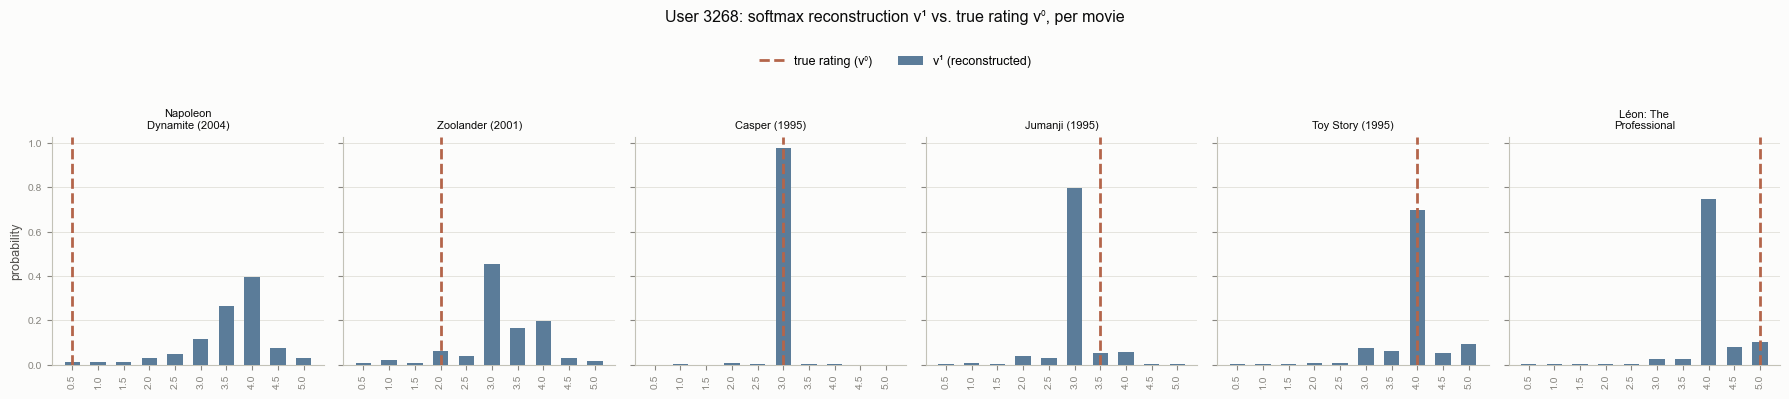

In [11]:
# Step 2, part A: h0 -> softmax over each movie's K rating bins -> v1 (reconstruction)
J_v = (h0 @ W_plus.T).reshape(n_movies, K)          # no visible bias, same omission as e+'s trained form
J_v_shift = J_v - J_v.max(axis=1, keepdims=True)     # numerical stability, does not change the softmax result
exp_J = np.exp(J_v_shift)
v1_full = exp_J / exp_J.sum(axis=1, keepdims=True)   # softmax per movie row -- every row sums to 1

mask_col = np.asarray(mask[demo_row]).astype(np.float64)   # (n_movies,)
v1 = v1_full * mask_col[:, None]                     # masking: same treatment as Step 1, only rated movies kept

row_sums = v1.sum(axis=1)
print(f"v1 row sums at RATED movies:   min={row_sums[rated_cols].min():.4f}  max={row_sums[rated_cols].max():.4f}  (should = 1.0)")
print(f"v1 row sums at UNRATED movies: min={row_sums[unrated_cols].min():.4f}  max={row_sums[unrated_cols].max():.4f}  (should = 0.0)")

import textwrap

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
TRUE_COLOR, RECON_COLOR = "#b4654a", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

def wrap_title(t, width=16, max_lines=2):
    t = t.split(" (a.k.a")[0]  # drop redundant alt-title suffixes, e.g. "Leon ... (a.k.a. The Professional)"
    lines = textwrap.wrap(t, width)
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + "..."
    return "\n".join(lines)

n_sample = len(picked_idx)
fig, axes = plt.subplots(1, n_sample, figsize=(3.0 * n_sample, 3.4), facecolor=SURFACE, sharey=True)
if n_sample == 1:
    axes = [axes]

x = np.arange(K)
for ax, pidx, title in zip(axes, picked_idx, sample_titles):
    movie_col = cols_demo[pidx]
    true_row = block_demo[pidx]
    recon_row = v1[movie_col]
    ax.set_facecolor(SURFACE)
    ax.bar(x, recon_row, color=RECON_COLOR, width=0.6, zorder=3, label="v¹ (reconstructed)")
    true_k = int(true_row.argmax())
    ax.axvline(true_k, color=TRUE_COLOR, linewidth=2, linestyle="--", zorder=4, label="true rating (v⁰)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{r:.1f}" for r in RATING_LEVELS], rotation=90, fontsize=7)
    ax.set_title(wrap_title(title), fontsize=8, color=INK_PRIMARY)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=7.5)
    ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)

axes[0].set_ylabel("probability", color=INK_SECONDARY, fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.06))
fig.suptitle(f"User {DEMO_USER_ID}: softmax reconstruction v¹ vs. true rating v⁰, per movie", fontsize=11.5, color=INK_PRIMARY, y=1.16)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step2_softmax.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


##### $v^1$ as a table, same format as $v^0$'s one-hot table -- but probabilities, not 0/1


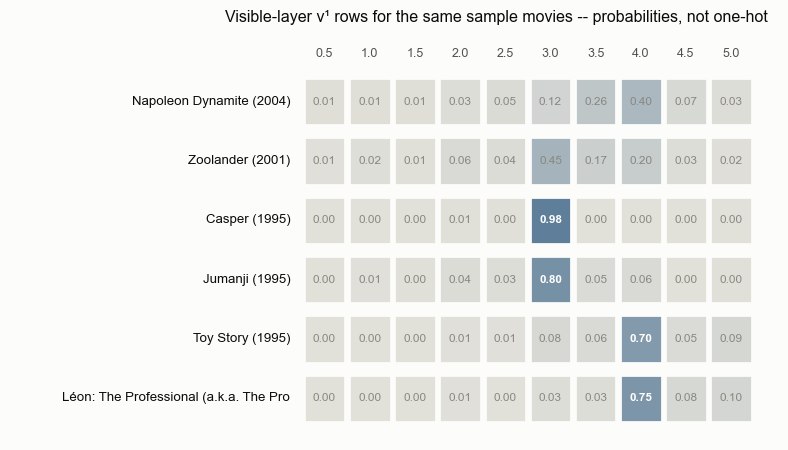

In [12]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_RGB, ONE_RGB = (0xe1, 0xe0, 0xd9), (0x5b, 0x7c, 0x99)  # same two colors as v0's grid, blended by value now
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]


def blend(val):
    r = ZERO_RGB[0] + (ONE_RGB[0] - ZERO_RGB[0]) * val
    g = ZERO_RGB[1] + (ONE_RGB[1] - ZERO_RGB[1]) * val
    b = ZERO_RGB[2] + (ONE_RGB[2] - ZERO_RGB[2]) * val
    return (r / 255, g / 255, b / 255)


n_sample = len(sample_titles)
fig, ax = plt.subplots(figsize=(8, 0.55 * n_sample + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for row_i, (t, pidx) in enumerate(zip(sample_titles, picked_idx)):
    row_v1 = v1[cols_demo[pidx]]  # this movie's reconstructed probability distribution, K values summing to 1
    for col_j in range(K):
        val = float(row_v1[col_j])
        color = blend(val)
        ax.add_patch(plt.Rectangle((col_j, n_sample - 1 - row_i), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
        txt_color = "white" if val > 0.5 else INK_MUTED
        ax.text(col_j + 0.46, n_sample - 1 - row_i + 0.4, f"{val:.2f}", ha="center", va="center", fontsize=8.5, color=txt_color, fontweight="bold" if val > 0.5 else "normal")
    ax.text(-0.3, n_sample - 1 - row_i + 0.4, t[:38], ha="right", va="center", fontsize=9.5, color=INK_PRIMARY)

for col_j, r in enumerate(RATING_LEVELS):
    ax.text(col_j + 0.46, n_sample + 0.15, f"{r:.1f}", ha="center", fontsize=9, color=INK_SECONDARY)

ax.set_xlim(-6.5, K + 0.5)
ax.set_ylim(-0.3, n_sample + 0.6)
ax.axis("off")
ax.set_title("Visible-layer v¹ rows for the same sample movies -- probabilities, not one-hot", color=INK_PRIMARY, fontsize=11.5, loc="left", x=0.28)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_v1_detail.png", dpi=150, facecolor=SURFACE)
plt.show()


##### $v^1 \to h^1$: sigmoid, probabilities only


I_j (from v1):          min=2.6623  max=11.7675  mean=6.5826
h1_prob = sigma(I_j):   min=0.9348  max=1.0000  mean=0.9910
first 10 values: [0.999 0.995 1.    1.    1.    0.958 1.    0.953 0.974 1.   ]
(compare to h_prob_0 from Step 1, mean=0.8425 -- real data vs. reconstruction-driven)


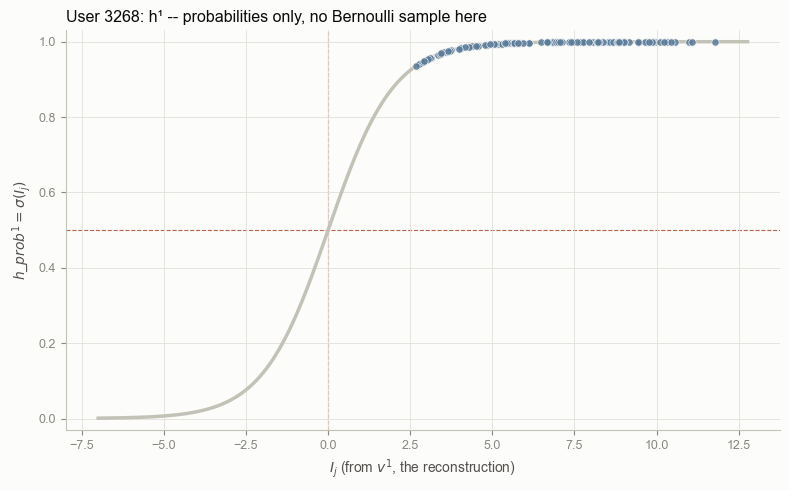


h1_prob - h_prob_0 per unit: min=-0.0009  max=0.8195  mean=0.1484
units where h1 < h0: 8 / 128   (diff is a continuum, not two separate groups -- colored by magnitude below, not binned)


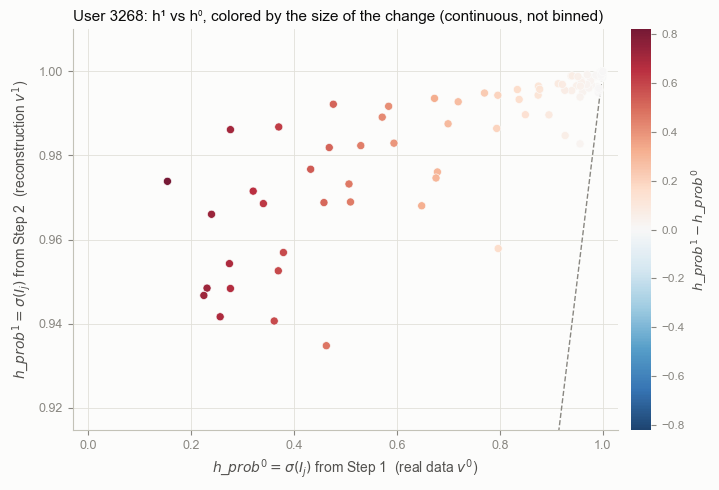

In [13]:
# Step 2, part B: v1 -> sigmoid -> h1 (probabilities only, no Bernoulli sample here)
I_j_1 = v1.reshape(-1) @ W_plus + bh_plus
h1_prob = sigmoid(I_j_1)
print(f"I_j (from v1):          min={I_j_1.min():.4f}  max={I_j_1.max():.4f}  mean={I_j_1.mean():.4f}")
print(f"h1_prob = sigma(I_j):   min={h1_prob.min():.4f}  max={h1_prob.max():.4f}  mean={h1_prob.mean():.4f}")
print(f"first 10 values: {np.round(h1_prob[:10], 3)}")
print(f"(compare to h_prob_0 from Step 1, mean={h_prob_0.mean():.4f} -- real data vs. reconstruction-driven)")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR, REF_COLOR = "#c3c2b7", "#5b7c99", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

x_curve = np.linspace(min(I_j_1.min(), -6) - 1, max(I_j_1.max(), 6) + 1, 400)
y_curve = sigmoid(x_curve)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
ax.scatter(I_j_1, h1_prob, color=DOT_COLOR, s=28, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.axhline(0.5, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xlabel(r"$I_j$ (from $v^1$, the reconstruction)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob^1=\sigma(I_j)$", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: h¹ -- probabilities only, no Bernoulli sample here", color=INK_PRIMARY, fontsize=11.5, loc="left")
ax.set_ylim(-0.03, 1.03)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step2_sigmoid.png", dpi=150, facecolor=SURFACE)
plt.show()


# ---- extra: h1_prob vs h_prob_0 -- for each hidden unit, is the change higher or lower, and by how much? ----
diff = h1_prob - h_prob_0
print(f"\nh1_prob - h_prob_0 per unit: min={diff.min():.4f}  max={diff.max():.4f}  mean={diff.mean():.4f}")
print(f"units where h1 < h0: {int((diff < 0).sum())} / {n_hidden}   (diff is a continuum, not two separate groups -- colored by magnitude below, not binned)")

y_lo = max(0.0, float(h1_prob.min()) - 0.02)
y_hi = min(1.01, float(h1_prob.max()) + 0.01)

fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
sc = ax.scatter(h_prob_0, h1_prob, c=diff, cmap="RdBu_r", vmin=-diff.max(), vmax=diff.max(),
                 s=34, zorder=3, alpha=0.9, edgecolors=SURFACE, linewidths=0.5)
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$h\_prob^1 - h\_prob^0$", color=INK_SECONDARY, fontsize=9.5)
cbar.ax.tick_params(colors=INK_MUTED, labelsize=8.5)
cbar.outline.set_visible(False)
ax.set_xlabel(r"$h\_prob^0=\sigma(I_j)$ from Step 1  (real data $v^0$)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob^1=\sigma(I_j)$ from Step 2  (reconstruction $v^1$)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: h¹ vs h⁰, colored by the size of the change (continuous, not binned)", color=INK_PRIMARY, fontsize=11, loc="left")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(y_lo, y_hi)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step2_h0_vs_h1.png", dpi=150, facecolor=SURFACE)
plt.show()


## Step 3 — Gradient estimate: $\Delta W_{(i,k),j} = \langle v_{i,k} h_j \rangle_{\text{data}} - \langle v_{i,k} h_j \rangle_{\text{recon}}$

This is the point of the whole CD-1 dance: contrasting statistics collected from the real data (Step 1) against statistics collected from the model's own reconstruction (Step 2) gives the direction to nudge each weight.

$$\langle v_{i,k} h_j \rangle_{\text{data}} := v^0_{i,k}\, h^0_j \qquad\qquad \langle v_{i,k} h_j \rangle_{\text{recon}} := v^1_{i,k}\, h^1_j$$

For the *data* term we use $h^0$, the Bernoulli sample from Step 1. For the *recon* term we use $h^1$ as a probability (no Bernoulli sample), matching the choice made in Step 2. Masking: $v^0$ and $v^1$ are already zero at every unrated movie, so $\Delta W$ is automatically zero there too -- no separate masking step needed, but it's verified below rather than assumed.

This is a **single-user** estimate. In real training, $\Delta W$ gets averaged over an entire batch of users before being scaled by the learning rate and applied to $W$.


##### $\Delta W$ = data statistics $-$ reconstruction statistics


pos  (data):  shape=(131290, 128)  nonzero=72384  sum=72384.0000
neg  (recon): shape=(131290, 128)  nonzero=890880  sum=88281.8766
delta_W = pos - neg: sum=-15897.8766
max |delta_W| at UNRATED movies: 0.000000  (should = 0.0 -- masking carries through automatically)
delta_W at RATED movies: min=-1.0000  max=1.0000  mean=-0.017845


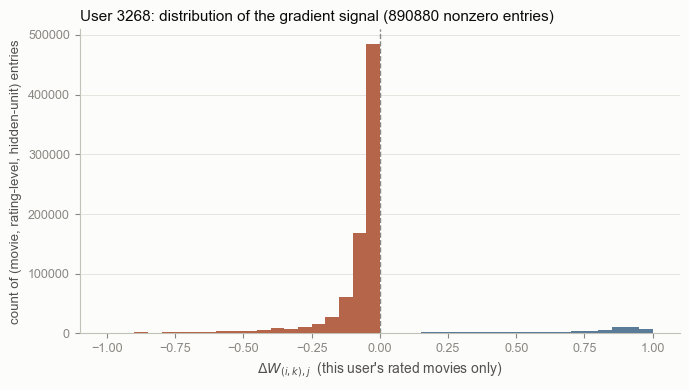

In [14]:
# Step 3: contrastive gradient estimate, this one user's contribution
pos = np.outer(v0, h0)          # <v h>_data,  from Step 1 (real v0, sampled h0)
neg = np.outer(v1, h1_prob)     # <v h>_recon, from Step 2 (reconstructed v1, probability h1)
delta_W = pos - neg

print(f"pos  (data):  shape={pos.shape}  nonzero={int((pos != 0).sum())}  sum={pos.sum():.4f}")
print(f"neg  (recon): shape={neg.shape}  nonzero={int((neg != 0).sum())}  sum={neg.sum():.4f}")
print(f"delta_W = pos - neg: sum={delta_W.sum():.4f}")

delta_W_reshaped = delta_W.reshape(n_movies, K, n_hidden)
unrated_max_abs = float(np.abs(delta_W_reshaped[unrated_cols]).max())
rated_vals = delta_W_reshaped[rated_cols].reshape(-1)
print(f"max |delta_W| at UNRATED movies: {unrated_max_abs:.6f}  (should = 0.0 -- masking carries through automatically)")
print(f"delta_W at RATED movies: min={rated_vals.min():.4f}  max={rated_vals.max():.4f}  mean={rated_vals.mean():.6f}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
POS_COLOR, NEG_COLOR = "#5b7c99", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

nonzero_vals = rated_vals[rated_vals != 0]
fig, ax = plt.subplots(figsize=(7, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
counts, bins, patches = ax.hist(nonzero_vals, bins=40, color=POS_COLOR, zorder=3)
for patch, edge in zip(patches, bins[:-1]):
    if edge < 0:
        patch.set_facecolor(NEG_COLOR)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
ax.set_xlabel(r"$\Delta W_{(i,k),j}$  (this user's rated movies only)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("count of (movie, rating-level, hidden-unit) entries", color=INK_SECONDARY, fontsize=9.5)
ax.set_title(f"User {DEMO_USER_ID}: distribution of the gradient signal ({len(nonzero_vals)} nonzero entries)", color=INK_PRIMARY, fontsize=11, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step3_gradient_hist.png", dpi=150, facecolor=SURFACE)
plt.show()


##### $\Delta W$ for one movie's true-rating column, across all 128 hidden units


Casper (1995), true rating column k=3.0:
  delta_W across 128 hidden units: min=-0.9739  max=0.0798
  104 units pushed UP (strengthen this movie-rating link), 24 pushed DOWN


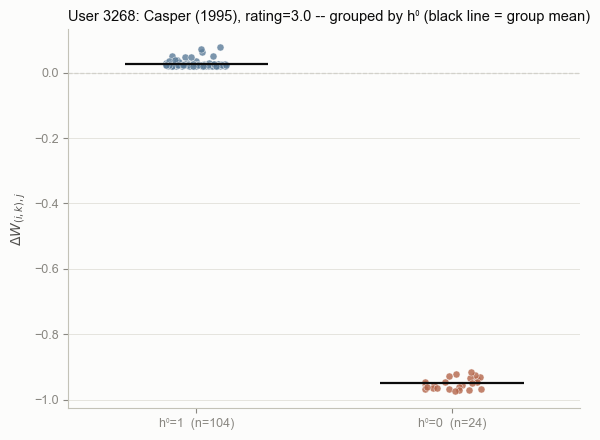

In [15]:
# Zoom into ONE rated movie -- Casper, true rating 3.0 -- and look at every hidden unit's push for that column
example_title = "Casper (1995)"
example_pidx = picked_idx[sample_titles.index(next(t for t in sample_titles if t.startswith("Casper")))]
example_movie_col = cols_demo[example_pidx]
example_true_k = int(block_demo[example_pidx].argmax())

delta_W_row = delta_W_reshaped[example_movie_col, example_true_k, :]   # (n_hidden,), one value per hidden unit
print(f"{example_title}, true rating column k={RATING_LEVELS[example_true_k]:.1f}:")
print(f"  delta_W across {n_hidden} hidden units: min={delta_W_row.min():.4f}  max={delta_W_row.max():.4f}")
print(f"  {int((delta_W_row > 0).sum())} units pushed UP (strengthen this movie-rating link), "
      f"{int((delta_W_row < 0).sum())} pushed DOWN")

# group by this movie's h0 status, since that's what splits the two clusters (see Step 1's Bernoulli sample)
group_on, group_off = delta_W_row[h0 == 1], delta_W_row[h0 == 0]

rng_jitter = np.random.default_rng(2)
x_on = 0 + rng_jitter.uniform(-0.12, 0.12, size=len(group_on))
x_off = 1 + rng_jitter.uniform(-0.12, 0.12, size=len(group_off))

fig, ax = plt.subplots(figsize=(6, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.scatter(x_on, group_on, color=POS_COLOR, s=26, zorder=3, alpha=0.8, edgecolors=SURFACE, linewidths=0.4)
ax.scatter(x_off, group_off, color=NEG_COLOR, s=26, zorder=3, alpha=0.8, edgecolors=SURFACE, linewidths=0.4)
ax.hlines(group_on.mean(), -0.28, 0.28, color=INK_PRIMARY, linewidth=1.6, zorder=4)
ax.hlines(group_off.mean(), 0.72, 1.28, color=INK_PRIMARY, linewidth=1.6, zorder=4)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"h⁰=1  (n={len(group_on)})", f"h⁰=0  (n={len(group_off)})"], fontsize=9.5)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel(r"$\Delta W_{(i,k),j}$", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: {example_title}, rating={RATING_LEVELS[example_true_k]:.1f} -- grouped by h⁰ (black line = group mean)", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step3_gradient_movie.png", dpi=150, facecolor=SURFACE)
plt.show()


## Step 4 — Weight update: $W \leftarrow W + \eta \Delta W$, biases the same way

$$W_{(i,k),j} \leftarrow W_{(i,k),j} + \eta\, \Delta W_{(i,k),j}$$

$$b_j \leftarrow b_j + \eta\, \Delta b_j, \qquad \Delta b_j := \langle h_j \rangle_{\text{data}} - \langle h_j \rangle_{\text{recon}} = h^0_j - h^1_j$$

$\eta = 0.01$ -- the same learning rate actually used in 13b's training (`LR` in `train_rbm`). There is no visible bias term to update, consistent with everything built so far: e+'s trained model does not have one.

In real training, $\Delta W$ and $\Delta b$ are averaged over a whole batch of 500 users (`BATCH_SIZE` in 13b) before this update is applied. Here we apply it as if this single user's gradient were the whole batch, purely to show the mechanics -- this is illustrative only and does not modify the actual saved `W_plus` / `bh_plus`.


##### Applying the update (illustrative -- one user standing in for a batch)


delta_b_h: min=-0.9955  max=0.0594  mean=-0.1785
W shift (LR * delta_W), rated-movie entries only: min=-0.0097  max=0.0097
for comparison, W itself has std~0.01-0.02 (from prior inspection) -- one user's update is a small nudge, not a big jump; training needs many batches x many epochs to add up


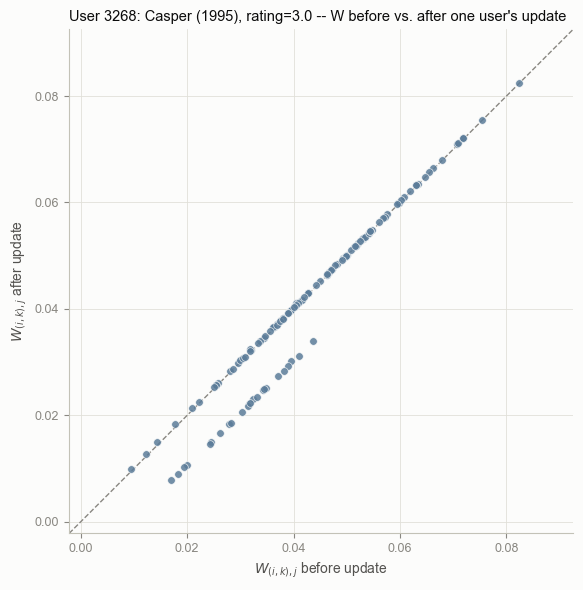

In [16]:
# Step 4: apply the update, using the same LR actually used in 13b's real training
LR = 0.01

delta_b_h = h0 - h1_prob   # <h>_data - <h>_recon, per hidden unit -- Step 3's contrast, applied to the bias
W_updated = W_plus + LR * delta_W
bh_updated = bh_plus + LR * delta_b_h

w_shift = (W_updated - W_plus)[rated_cols].reshape(-1)
print(f"delta_b_h: min={delta_b_h.min():.4f}  max={delta_b_h.max():.4f}  mean={delta_b_h.mean():.4f}")
print(f"W shift (LR * delta_W), rated-movie entries only: min={w_shift.min():.4f}  max={w_shift.max():.4f}")
print(f"for comparison, W itself has std~0.01-0.02 (from prior inspection) -- "
      f"one user's update is a small nudge, not a big jump; training needs many batches x many epochs to add up")

import matplotlib.pyplot as plt

CURVE_COLOR = "#c3c2b7"

fig, ax = plt.subplots(figsize=(6, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
w_before = W_plus[example_movie_col, :] if "example_movie_col" not in dir() else W_plus.reshape(n_movies, K, n_hidden)[example_movie_col, example_true_k, :]
w_after = W_updated.reshape(n_movies, K, n_hidden)[example_movie_col, example_true_k, :]
lo = min(w_before.min(), w_after.min()) - 0.01
hi = max(w_before.max(), w_after.max()) + 0.01
ax.plot([lo, hi], [lo, hi], color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
ax.scatter(w_before, w_after, color=POS_COLOR, s=30, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.set_xlabel(r"$W_{(i,k),j}$ before update", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$W_{(i,k),j}$ after update", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: {example_title}, rating={RATING_LEVELS[example_true_k]:.1f} -- W before vs. after one user's update", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.set_xlim(lo, hi)
ax.set_ylim(lo, hi)
ax.set_aspect("equal")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_step4_update.png", dpi=150, facecolor=SURFACE)
plt.show()


## e− — same CD-1 mechanics, different input

Everything below reuses the exact same masking / sigmoid / Bernoulli mechanics already verified for e+ (Steps 1-4 above). The only thing that changes is **what the input represents**:

| | e+ | e− |
|---|---|---|
| data file | `channelB1_softmax.npy` | `channelDminus_5k.npy` |
| weights | `rbmB1_weights_5k.npy` / `rbmB1_bias_hidden_5k.npy` | `rbmDminus_weights_5k.npy` / `rbmDminus_bias_hidden_5k.npy` |
| K=10 bins mean | absolute rating level (0.5 ... 5.0) | deviation from this user's own train-mean rating, K=10 **symmetric** bins around 0 |
| trained in | notebook 13b | notebook 19 |

Both were trained with identical hyperparameters (`N_HIDDEN=128, LR=0.01, BATCH_SIZE=500, EPOCHS=50, INIT_SEED=42`) -- only the encoded meaning of $v$ differs.


In [17]:
W_minus = np.load(proc / "rbmDminus_weights_5k.npy")
bh_minus = np.load(proc / "rbmDminus_bias_hidden_5k.npy")
channelDminus = np.load(proc / "channelDminus_5k.npy", mmap_mode="r")
bin_edges = np.load(proc / "deviation_bin_edges_5k.npy")
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

print(f"e- : W {W_minus.shape}  bh {bh_minus.shape}  (frozen, trained in 19)")
print(f"channelDminus: {channelDminus.shape}")
print(f"deviation bin edges:   {np.round(bin_edges, 3)}")
print(f"deviation bin centers: {np.round(bin_centers, 3)}")


e- : W (131290, 128)  bh (128,)  (frozen, trained in 19)
channelDminus: (5000, 13129, 10)
deviation bin edges:   [-3.956 -3.165 -2.374 -1.582 -0.791  0.     0.791  1.582  2.374  3.165
  3.956]
deviation bin centers: [-3.56  -2.769 -1.978 -1.187 -0.396  0.396  1.187  1.978  2.769  3.56 ]


##### The input, in detail: same movies, but the bin now means "deviation from your own mean"

In [18]:
# same demo user, same sample movies as e+'s onehot-detail-code -- but decoded from channelDminus, not channelB1
v0_m = np.asarray(channelDminus[demo_row]).reshape(-1).astype(np.float64)
block_demo_m = np.asarray(channelDminus[demo_row, cols_demo, :])
user_mean = ratings_demo.mean()

print(f"User {DEMO_USER_ID}: train-mean rating = {user_mean:.4f}  (this is the reference point e- measures deviation from)\n")
print("Same 6 sample movies, e- input this time:")
for t, pidx in zip(sample_titles, picked_idx):
    row_oh_m = block_demo_m[pidx]
    k_hot = int(row_oh_m.argmax())
    real_rating = ratings_demo[pidx]
    print(f"  {t[:38]:38s} real_rating={real_rating:.1f}  deviation={real_rating - user_mean:+.2f}  "
          f"-> bin {k_hot} (center {bin_centers[k_hot]:+.2f})  onehot={row_oh_m.astype(int).tolist()}")


User 3268: train-mean rating = 3.6466  (this is the reference point e- measures deviation from)

Same 6 sample movies, e- input this time:
  Napoleon Dynamite (2004)               real_rating=0.5  deviation=-3.15  -> bin 1 (center -2.77)  onehot=[0, 1, 0, 0, 0, 0, 0, 0, 0, 0]
  Zoolander (2001)                       real_rating=2.0  deviation=-1.65  -> bin 2 (center -1.98)  onehot=[0, 0, 1, 0, 0, 0, 0, 0, 0, 0]
  Casper (1995)                          real_rating=3.0  deviation=-0.65  -> bin 4 (center -0.40)  onehot=[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Jumanji (1995)                         real_rating=3.5  deviation=-0.15  -> bin 4 (center -0.40)  onehot=[0, 0, 0, 0, 1, 0, 0, 0, 0, 0]
  Toy Story (1995)                       real_rating=4.0  deviation=+0.35  -> bin 5 (center +0.40)  onehot=[0, 0, 0, 0, 0, 1, 0, 0, 0, 0]
  Léon: The Professional (a.k.a. The Pro real_rating=5.0  deviation=+1.35  -> bin 6 (center +1.19)  onehot=[0, 0, 0, 0, 0, 0, 1, 0, 0, 0]


##### Same grid format as e+'s input table, columns are now deviation bins

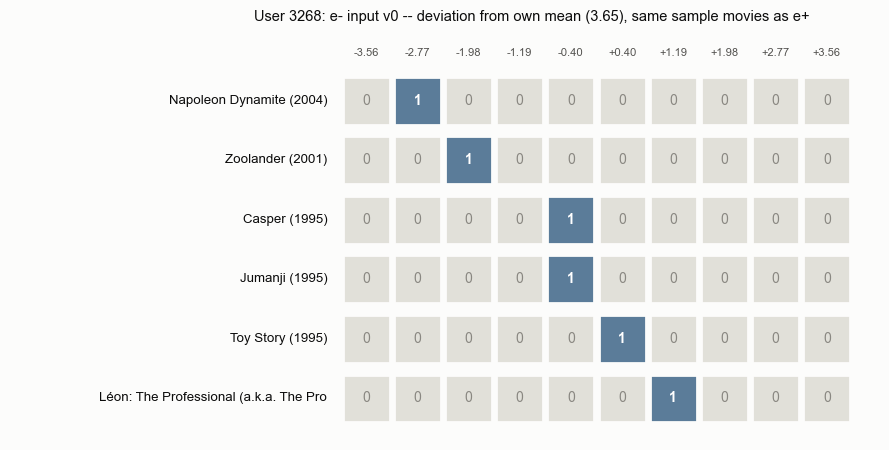

In [19]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_COLOR, ONE_COLOR = "#e1e0d9", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

n_sample = len(sample_titles)
fig, ax = plt.subplots(figsize=(9, 0.55 * n_sample + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for row_i, (t, pidx) in enumerate(zip(sample_titles, picked_idx)):
    row_oh_m = block_demo_m[pidx]
    for col_j in range(K):
        val = int(row_oh_m[col_j])
        color = ONE_COLOR if val == 1 else ZERO_COLOR
        ax.add_patch(plt.Rectangle((col_j, n_sample - 1 - row_i), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
        txt_color = "white" if val == 1 else INK_MUTED
        ax.text(col_j + 0.46, n_sample - 1 - row_i + 0.4, str(val), ha="center", va="center", fontsize=10, color=txt_color, fontweight="bold" if val else "normal")
    ax.text(-0.3, n_sample - 1 - row_i + 0.4, t[:38], ha="right", va="center", fontsize=9.5, color=INK_PRIMARY)

for col_j in range(K):
    ax.text(col_j + 0.46, n_sample + 0.15, f"{bin_centers[col_j]:+.2f}", ha="center", fontsize=8, color=INK_SECONDARY)

ax.set_xlim(-6.5, K + 0.5)
ax.set_ylim(-0.3, n_sample + 0.6)
ax.axis("off")
ax.set_title(f"User {DEMO_USER_ID}: e- input v0 -- deviation from own mean ({user_mean:.2f}), same sample movies as e+", color=INK_PRIMARY, fontsize=10.5, loc="left", x=0.28)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_input_detail.png", dpi=150, facecolor=SURFACE)
plt.show()


### e− Step 1 — positive phase, mechanically identical to e+

$$I_j := b_j + \sum_{i,k} v^0_{i,k} W_{(i,k),j} \qquad h^0_j \sim \text{Bernoulli}(\sigma(I_j))$$

Same formula, same masking rule (only this user's rated, train-split movies contribute) -- just $v^0$, $W$, $b$ all swapped for e-'s own.


##### Masking, verified (same check as e+)

In [20]:
rated_cols_m = np.where(np.asarray(mask[demo_row]) == 1)[0]
unrated_cols_m = np.where(np.asarray(mask[demo_row]) == 0)[0]
v0_m_reshaped = v0_m.reshape(n_movies, K)
print(f"v0_m: {int((v0_m != 0).sum())} nonzero entries total")
print(f"  at RATED positions ({len(rated_cols_m)} movies): {int(v0_m_reshaped[rated_cols_m].sum())} ones (should = {len(rated_cols_m)})")
print(f"  at UNRATED positions ({len(unrated_cols_m)} movies): {int(v0_m_reshaped[unrated_cols_m].sum())} ones (should = 0)")


v0_m: 696 nonzero entries total
  at RATED positions (696 movies): 696 ones (should = 696)
  at UNRATED positions (12433 movies): 0 ones (should = 0)


##### Sigmoid: same S-curve, driven by e-'s own $I_j$

I_j_m:         min=0.9182  max=4.3964  mean=2.6219
h_prob_0_m = sigma(I_j_m):  min=0.7147  max=0.9878  mean=0.9212
first 10 values: [0.851 0.931 0.849 0.968 0.917 0.827 0.946 0.901 0.926 0.95 ]
(compare to e+'s h_prob_0: mean=0.8425)


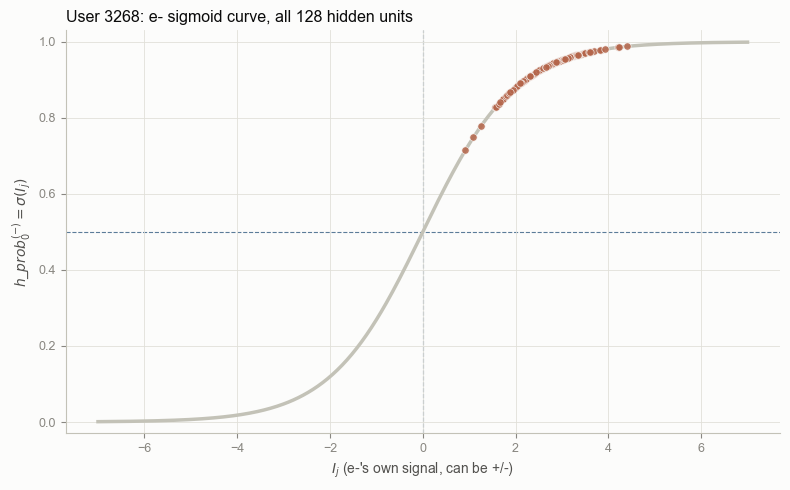

In [21]:
I_j_m = v0_m @ W_minus + bh_minus
h_prob_0_m = sigmoid(I_j_m)
print(f"I_j_m:         min={I_j_m.min():.4f}  max={I_j_m.max():.4f}  mean={I_j_m.mean():.4f}")
print(f"h_prob_0_m = sigma(I_j_m):  min={h_prob_0_m.min():.4f}  max={h_prob_0_m.max():.4f}  mean={h_prob_0_m.mean():.4f}")
print(f"first 10 values: {np.round(h_prob_0_m[:10], 3)}")
print(f"(compare to e+'s h_prob_0: mean={h_prob_0.mean():.4f})")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR, REF_COLOR = "#c3c2b7", "#b4654a", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

x_curve = np.linspace(min(I_j_m.min(), -6) - 1, max(I_j_m.max(), 6) + 1, 400)
y_curve = sigmoid(x_curve)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
ax.scatter(I_j_m, h_prob_0_m, color=DOT_COLOR, s=28, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.axhline(0.5, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xlabel(r"$I_j$ (e-'s own signal, can be +/-)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob_0^{(-)} = \sigma(I_j)$", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- sigmoid curve, all {n_hidden} hidden units", color=INK_PRIMARY, fontsize=11.5, loc="left")
ax.set_ylim(-0.03, 1.03)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step1_sigmoid.png", dpi=150, facecolor=SURFACE)
plt.show()


##### Bernoulli sample: $h^{0,(-)}$

h0_m: 116 / 128 units sampled ON  (compare e+: 104 / 128)


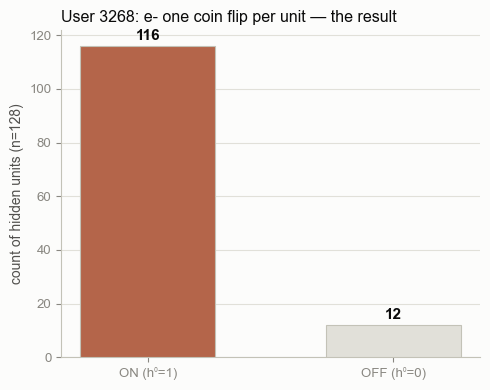

In [22]:
rng_cd1_m = np.random.default_rng(0)
h0_m = (rng_cd1_m.random(h_prob_0_m.shape) < h_prob_0_m).astype(np.float64)
print(f"h0_m: {int(h0_m.sum())} / {n_hidden} units sampled ON  (compare e+: {int(h0.sum())} / {n_hidden})")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
ON_COLOR, OFF_COLOR = "#b4654a", "#e1e0d9"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

n_on_m, n_off_m = int(h0_m.sum()), int(n_hidden - h0_m.sum())
fig, ax = plt.subplots(figsize=(5, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
bars = ax.bar(["ON (h⁰=1)", "OFF (h⁰=0)"], [n_on_m, n_off_m], color=[ON_COLOR, OFF_COLOR], width=0.55, zorder=3, edgecolor=BASELINE, linewidth=0.8)
for b, v in zip(bars, [n_on_m, n_off_m]):
    ax.text(b.get_x() + b.get_width() / 2, v + max(n_on_m, n_off_m) * 0.02, f"{v}", ha="center", fontsize=11, color=INK_PRIMARY, fontweight="bold")
ax.set_ylabel(f"count of hidden units (n={n_hidden})", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- one coin flip per unit — the result", color=INK_PRIMARY, fontsize=11.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9.5)
ax.grid(axis="y", color=GRID, linewidth=0.8, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step1_bernoulli.png", dpi=150, facecolor=SURFACE)
plt.show()


### e− Step 2 — Reconstruction: h⁰ → v¹ → h¹ (same softmax + sigmoid rule as e+)

$$J_{i,k} := \sum_j W^{(-)}_{(i,k),j}\, h^{0,(-)}_j \qquad v^{1,(-)}_{i,k} = \frac{\exp(J_{i,k})}{\sum_{k'} \exp(J_{i,k'})}$$

Same softmax-over-K-bins rule (SMH 2007) as e+ -- the only difference is the K bins are deviation bins now, not absolute rating levels. $h^{1,(-)}$ is again probabilities only, no Bernoulli sample, same choice as e+.


##### $h^{0,(-)} \to v^{1,(-)}$: softmax reconstruction, per movie

v1_m row sums at RATED movies:   min=1.0000  max=1.0000  (should = 1.0)
v1_m row sums at UNRATED movies: min=0.0000  max=0.0000  (should = 0.0)


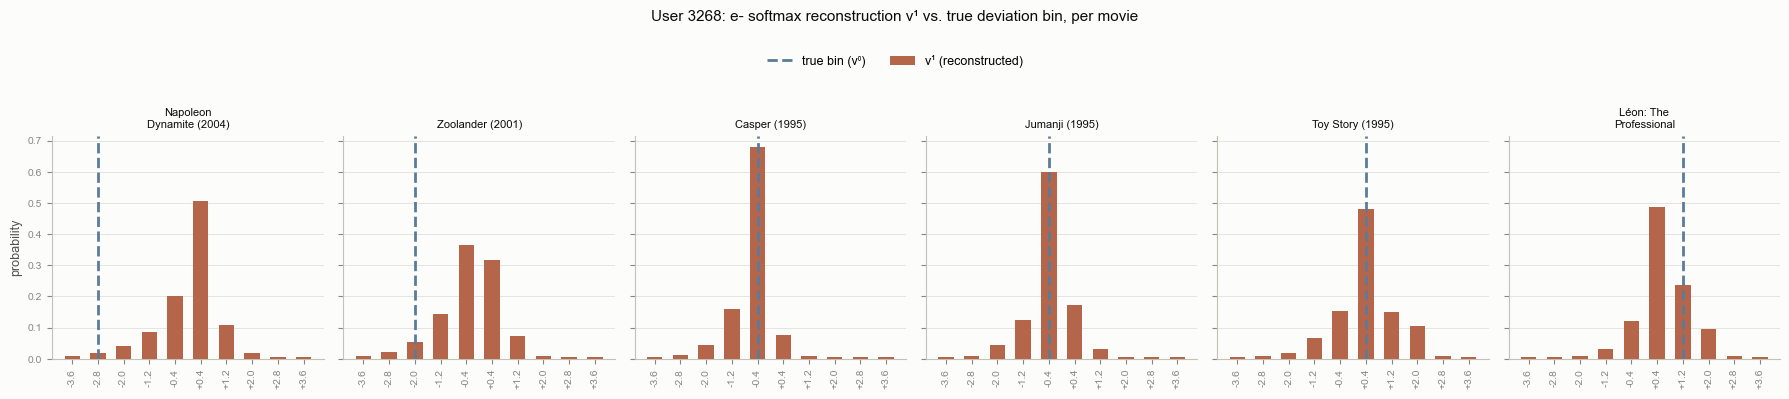

In [23]:
# e- Step 2, part A: h0_m -> softmax over each movie's K deviation bins -> v1_m
J_v_m = (h0_m @ W_minus.T).reshape(n_movies, K)
J_v_m_shift = J_v_m - J_v_m.max(axis=1, keepdims=True)
exp_J_m = np.exp(J_v_m_shift)
v1_m_full = exp_J_m / exp_J_m.sum(axis=1, keepdims=True)

v1_m = v1_m_full * mask_col[:, None]   # same mask_col as e+ (same user, same rated/unrated movies)

row_sums_m = v1_m.sum(axis=1)
print(f"v1_m row sums at RATED movies:   min={row_sums_m[rated_cols_m].min():.4f}  max={row_sums_m[rated_cols_m].max():.4f}  (should = 1.0)")
print(f"v1_m row sums at UNRATED movies: min={row_sums_m[unrated_cols_m].min():.4f}  max={row_sums_m[unrated_cols_m].max():.4f}  (should = 0.0)")

import textwrap

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
TRUE_COLOR, RECON_COLOR = "#5b7c99", "#b4654a"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

def wrap_title(t, width=16, max_lines=2):
    t = t.split(" (a.k.a")[0]
    lines = textwrap.wrap(t, width)
    if len(lines) > max_lines:
        lines = lines[:max_lines]
        lines[-1] = lines[-1].rstrip() + "..."
    return "\n".join(lines)

n_sample = len(picked_idx)
fig, axes = plt.subplots(1, n_sample, figsize=(3.0 * n_sample, 3.4), facecolor=SURFACE, sharey=True)
if n_sample == 1:
    axes = [axes]

x = np.arange(K)
for ax, pidx, title in zip(axes, picked_idx, sample_titles):
    movie_col = cols_demo[pidx]
    true_row_m = block_demo_m[pidx]
    recon_row_m = v1_m[movie_col]
    ax.set_facecolor(SURFACE)
    ax.bar(x, recon_row_m, color=RECON_COLOR, width=0.6, zorder=3, label="v¹ (reconstructed)")
    true_k_m = int(true_row_m.argmax())
    ax.axvline(true_k_m, color=TRUE_COLOR, linewidth=2, linestyle="--", zorder=4, label="true bin (v⁰)")
    ax.set_xticks(x)
    ax.set_xticklabels([f"{c:+.1f}" for c in bin_centers], rotation=90, fontsize=7)
    ax.set_title(wrap_title(title), fontsize=8, color=INK_PRIMARY)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
    for s in ("left", "bottom"):
        ax.spines[s].set_color(BASELINE)
    ax.tick_params(colors=INK_MUTED, labelsize=7.5)
    ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)

axes[0].set_ylabel("probability", color=INK_SECONDARY, fontsize=9)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=2, frameon=False, fontsize=9, bbox_to_anchor=(0.5, 1.06))
fig.suptitle(f"User {DEMO_USER_ID}: e- softmax reconstruction v¹ vs. true deviation bin, per movie", fontsize=11, color=INK_PRIMARY, y=1.16)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step2_softmax.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


##### $v^{1,(-)}$ as a table, same format -- probabilities over deviation bins

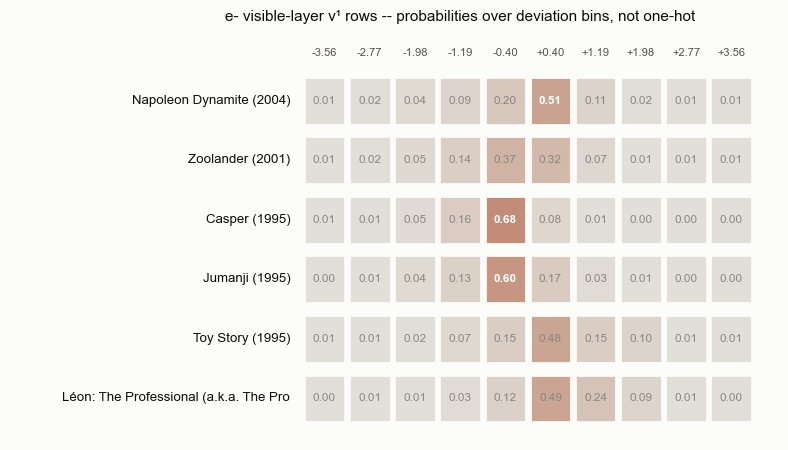

In [24]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
ZERO_RGB, ONE_RGB = (0xe1, 0xe0, 0xd9), (0xb4, 0x65, 0x4a)
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

def blend(val):
    r = ZERO_RGB[0] + (ONE_RGB[0] - ZERO_RGB[0]) * val
    g = ZERO_RGB[1] + (ONE_RGB[1] - ZERO_RGB[1]) * val
    b = ZERO_RGB[2] + (ONE_RGB[2] - ZERO_RGB[2]) * val
    return (r / 255, g / 255, b / 255)

n_sample = len(sample_titles)
fig, ax = plt.subplots(figsize=(8, 0.55 * n_sample + 1.3), facecolor=SURFACE)
ax.set_facecolor(SURFACE)

for row_i, (t, pidx) in enumerate(zip(sample_titles, picked_idx)):
    row_v1_m = v1_m[cols_demo[pidx]]
    for col_j in range(K):
        val = float(row_v1_m[col_j])
        color = blend(val)
        ax.add_patch(plt.Rectangle((col_j, n_sample - 1 - row_i), 0.92, 0.8, facecolor=color, edgecolor=SURFACE, linewidth=2))
        txt_color = "white" if val > 0.5 else INK_MUTED
        ax.text(col_j + 0.46, n_sample - 1 - row_i + 0.4, f"{val:.2f}", ha="center", va="center", fontsize=8.5, color=txt_color, fontweight="bold" if val > 0.5 else "normal")
    ax.text(-0.3, n_sample - 1 - row_i + 0.4, t[:38], ha="right", va="center", fontsize=9.5, color=INK_PRIMARY)

for col_j in range(K):
    ax.text(col_j + 0.46, n_sample + 0.15, f"{bin_centers[col_j]:+.2f}", ha="center", fontsize=8, color=INK_SECONDARY)

ax.set_xlim(-6.5, K + 0.5)
ax.set_ylim(-0.3, n_sample + 0.6)
ax.axis("off")
ax.set_title("e- visible-layer v¹ rows -- probabilities over deviation bins, not one-hot", color=INK_PRIMARY, fontsize=11, loc="left", x=0.28)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_v1_detail.png", dpi=150, facecolor=SURFACE)
plt.show()


##### $v^{1,(-)} \to h^{1,(-)}$: sigmoid, probabilities only

I_j (from v1_m):          min=0.1517  max=3.5968  mean=2.2236
h1_prob_m = sigma(I_j_m): min=0.5379  max=0.9733  mean=0.8839
(compare to e-'s h_prob_0_m from Step 1, mean=0.9212)


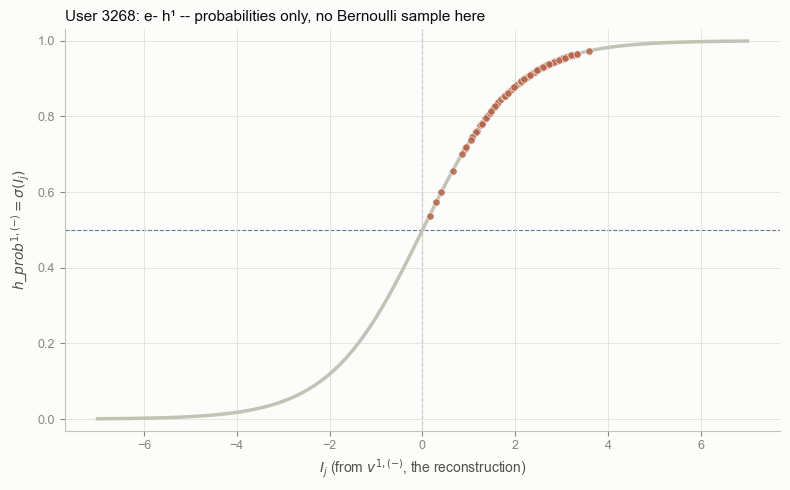


h1_prob_m - h_prob_0_m: min=-0.2106  max=0.0996  mean=-0.0372


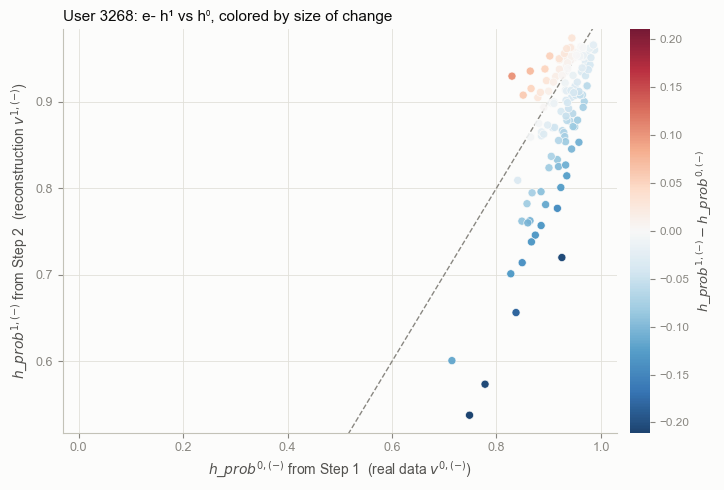

In [25]:
# e- Step 2, part B: v1_m -> sigmoid -> h1_m (probabilities only)
I_j_1_m = v1_m.reshape(-1) @ W_minus + bh_minus
h1_prob_m = sigmoid(I_j_1_m)
print(f"I_j (from v1_m):          min={I_j_1_m.min():.4f}  max={I_j_1_m.max():.4f}  mean={I_j_1_m.mean():.4f}")
print(f"h1_prob_m = sigma(I_j_m): min={h1_prob_m.min():.4f}  max={h1_prob_m.max():.4f}  mean={h1_prob_m.mean():.4f}")
print(f"(compare to e-'s h_prob_0_m from Step 1, mean={h_prob_0_m.mean():.4f})")

import matplotlib.pyplot as plt
import numpy as np

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
CURVE_COLOR, DOT_COLOR, REF_COLOR = "#c3c2b7", "#b4654a", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

x_curve = np.linspace(min(I_j_1_m.min(), -6) - 1, max(I_j_1_m.max(), 6) + 1, 400)
y_curve = sigmoid(x_curve)

fig, ax = plt.subplots(figsize=(8, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot(x_curve, y_curve, color=CURVE_COLOR, linewidth=2.5, zorder=2)
ax.scatter(I_j_1_m, h1_prob_m, color=DOT_COLOR, s=28, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.axhline(0.5, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.axvline(0, color=REF_COLOR, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xlabel(r"$I_j$ (from $v^{1,(-)}$, the reconstruction)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob^{1,(-)}=\sigma(I_j)$", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- h¹ -- probabilities only, no Bernoulli sample here", color=INK_PRIMARY, fontsize=11, loc="left")
ax.set_ylim(-0.03, 1.03)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step2_sigmoid.png", dpi=150, facecolor=SURFACE)
plt.show()

# ---- h1_prob_m vs h_prob_0_m, continuous color, same style as e+'s comparison ----
diff_m = h1_prob_m - h_prob_0_m
print(f"\nh1_prob_m - h_prob_0_m: min={diff_m.min():.4f}  max={diff_m.max():.4f}  mean={diff_m.mean():.4f}")

y_lo_m = max(0.0, float(h1_prob_m.min()) - 0.02)
y_hi_m = min(1.01, float(h1_prob_m.max()) + 0.01)

fig, ax = plt.subplots(figsize=(7.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.plot([0, 1], [0, 1], color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
sc = ax.scatter(h_prob_0_m, h1_prob_m, c=diff_m, cmap="RdBu_r", vmin=-max(abs(diff_m.min()), abs(diff_m.max())), vmax=max(abs(diff_m.min()), abs(diff_m.max())),
                 s=34, zorder=3, alpha=0.9, edgecolors=SURFACE, linewidths=0.5)
cbar = plt.colorbar(sc, ax=ax, pad=0.02)
cbar.set_label(r"$h\_prob^{1,(-)} - h\_prob^{0,(-)}$", color=INK_SECONDARY, fontsize=9.5)
cbar.ax.tick_params(colors=INK_MUTED, labelsize=8.5)
cbar.outline.set_visible(False)
ax.set_xlabel(r"$h\_prob^{0,(-)}$ from Step 1  (real data $v^{0,(-)}$)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$h\_prob^{1,(-)}$ from Step 2  (reconstruction $v^{1,(-)}$)", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- h¹ vs h⁰, colored by size of change", color=INK_PRIMARY, fontsize=11, loc="left")
ax.set_xlim(-0.03, 1.03)
ax.set_ylim(y_lo_m, y_hi_m)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step2_h0_vs_h1.png", dpi=150, facecolor=SURFACE)
plt.show()


### e− Step 3 — Gradient estimate: $\Delta W^{(-)} = \langle v h \rangle_{\text{data}} - \langle v h \rangle_{\text{recon}}$

Same contrast as e+, computed on e-'s own data/reconstruction pair.


##### $\Delta W^{(-)}$ = data statistics $-$ reconstruction statistics

pos_m  (data):  sum=80736.0000
neg_m  (recon): sum=78745.5801
delta_W_m = pos_m - neg_m: sum=1990.4199
max |delta_W_m| at UNRATED movies: 0.000000  (should = 0.0)
delta_W_m at RATED movies: min=-0.9674  max=0.9989  mean=0.002234


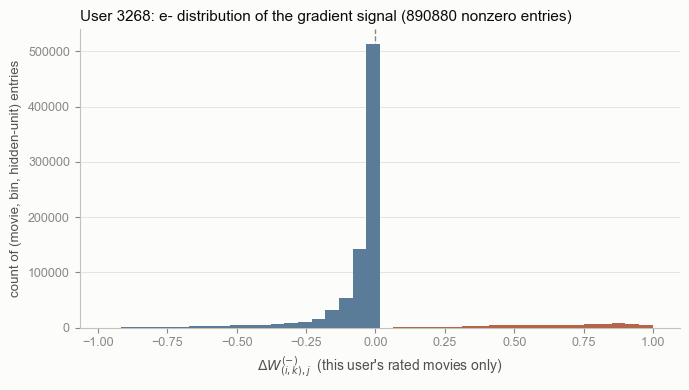

In [26]:
pos_m = np.outer(v0_m, h0_m)
neg_m = np.outer(v1_m, h1_prob_m)
delta_W_m = pos_m - neg_m

print(f"pos_m  (data):  sum={pos_m.sum():.4f}")
print(f"neg_m  (recon): sum={neg_m.sum():.4f}")
print(f"delta_W_m = pos_m - neg_m: sum={delta_W_m.sum():.4f}")

delta_W_m_reshaped = delta_W_m.reshape(n_movies, K, n_hidden)
unrated_max_abs_m = float(np.abs(delta_W_m_reshaped[unrated_cols_m]).max())
rated_vals_m = delta_W_m_reshaped[rated_cols_m].reshape(-1)
print(f"max |delta_W_m| at UNRATED movies: {unrated_max_abs_m:.6f}  (should = 0.0)")
print(f"delta_W_m at RATED movies: min={rated_vals_m.min():.4f}  max={rated_vals_m.max():.4f}  mean={rated_vals_m.mean():.6f}")

import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
POS_COLOR, NEG_COLOR = "#b4654a", "#5b7c99"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

nonzero_vals_m = rated_vals_m[rated_vals_m != 0]
fig, ax = plt.subplots(figsize=(7, 4), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
counts, bins_h, patches = ax.hist(nonzero_vals_m, bins=40, color=POS_COLOR, zorder=3)
for patch, edge in zip(patches, bins_h[:-1]):
    if edge < 0:
        patch.set_facecolor(NEG_COLOR)
ax.axvline(0, color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
ax.set_xlabel(r"$\Delta W^{(-)}_{(i,k),j}$  (this user's rated movies only)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("count of (movie, bin, hidden-unit) entries", color=INK_SECONDARY, fontsize=9.5)
ax.set_title(f"User {DEMO_USER_ID}: e- distribution of the gradient signal ({len(nonzero_vals_m)} nonzero entries)", color=INK_PRIMARY, fontsize=11, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step3_gradient_hist.png", dpi=150, facecolor=SURFACE)
plt.show()


##### $\Delta W^{(-)}$ for Casper's true deviation bin, across all 128 hidden units

Casper (1995), e- true deviation bin center=-0.40:
  delta_W_m across 128 hidden units: min=-0.6450  max=0.6339
  116 units pushed UP, 12 pushed DOWN


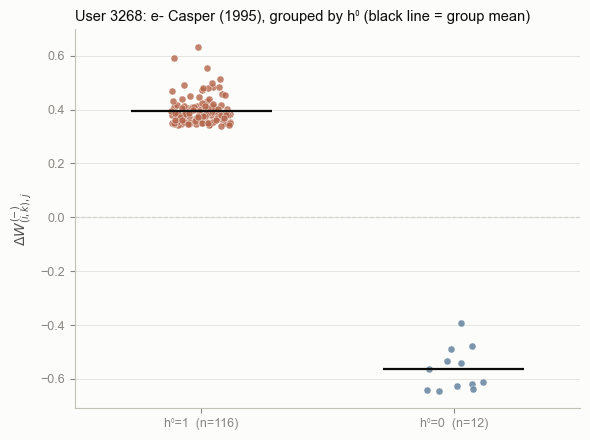

In [27]:
example_true_k_m = int(block_demo_m[example_pidx].argmax())
delta_W_m_row = delta_W_m_reshaped[example_movie_col, example_true_k_m, :]
print(f"{example_title}, e- true deviation bin center={bin_centers[example_true_k_m]:+.2f}:")
print(f"  delta_W_m across {n_hidden} hidden units: min={delta_W_m_row.min():.4f}  max={delta_W_m_row.max():.4f}")
print(f"  {int((delta_W_m_row > 0).sum())} units pushed UP, {int((delta_W_m_row < 0).sum())} pushed DOWN")

group_on_m, group_off_m = delta_W_m_row[h0_m == 1], delta_W_m_row[h0_m == 0]

rng_jitter_m = np.random.default_rng(2)
x_on_m = 0 + rng_jitter_m.uniform(-0.12, 0.12, size=len(group_on_m))
x_off_m = 1 + rng_jitter_m.uniform(-0.12, 0.12, size=len(group_off_m))

fig, ax = plt.subplots(figsize=(6, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.scatter(x_on_m, group_on_m, color=POS_COLOR, s=26, zorder=3, alpha=0.8, edgecolors=SURFACE, linewidths=0.4)
ax.scatter(x_off_m, group_off_m, color=NEG_COLOR, s=26, zorder=3, alpha=0.8, edgecolors=SURFACE, linewidths=0.4)
ax.hlines(group_on_m.mean(), -0.28, 0.28, color=INK_PRIMARY, linewidth=1.6, zorder=4)
ax.hlines(group_off_m.mean(), 0.72, 1.28, color=INK_PRIMARY, linewidth=1.6, zorder=4)
ax.axhline(0, color=INK_MUTED, linewidth=0.8, linestyle="--", zorder=1)
ax.set_xticks([0, 1])
ax.set_xticklabels([f"h⁰=1  (n={len(group_on_m)})", f"h⁰=0  (n={len(group_off_m)})"], fontsize=9.5)
ax.set_xlim(-0.5, 1.5)
ax.set_ylabel(r"$\Delta W^{(-)}_{(i,k),j}$", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- {example_title}, grouped by h⁰ (black line = group mean)", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step3_gradient_movie.png", dpi=150, facecolor=SURFACE)
plt.show()


### e− Step 4 — Weight update: $W^{(-)} \leftarrow W^{(-)} + \eta \Delta W^{(-)}$

Same $\eta=0.01$, same illustrative one-user-standing-in-for-a-batch caveat as e+.


##### Applying the update (illustrative, e-)

delta_b_h_m: min=-0.9475  max=0.4621  mean=0.0223
W_m shift (LR * delta_W_m), rated-movie entries only: min=-0.0072  max=0.0098


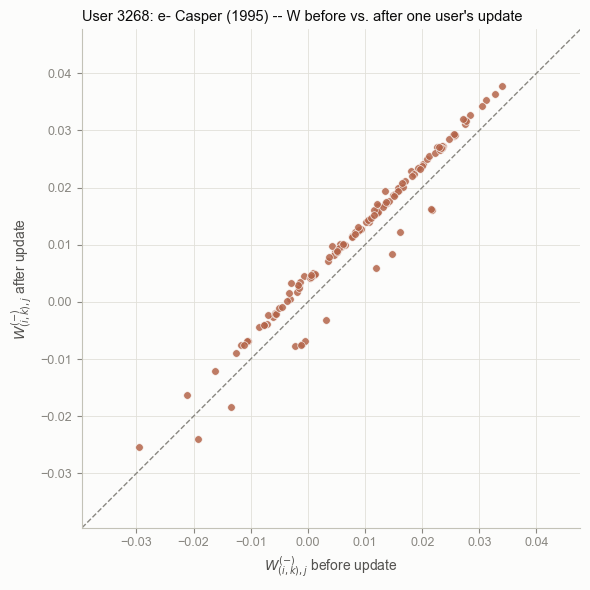

In [28]:
delta_b_h_m = h0_m - h1_prob_m
W_minus_updated = W_minus + LR * delta_W_m
bh_minus_updated = bh_minus + LR * delta_b_h_m

w_shift_m = (W_minus_updated - W_minus)[rated_cols_m].reshape(-1)
print(f"delta_b_h_m: min={delta_b_h_m.min():.4f}  max={delta_b_h_m.max():.4f}  mean={delta_b_h_m.mean():.4f}")
print(f"W_m shift (LR * delta_W_m), rated-movie entries only: min={w_shift_m.min():.4f}  max={w_shift_m.max():.4f}")

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 6), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
w_before_m = W_minus.reshape(n_movies, K, n_hidden)[example_movie_col, example_true_k_m, :]
w_after_m = W_minus_updated.reshape(n_movies, K, n_hidden)[example_movie_col, example_true_k_m, :]
lo_m = min(w_before_m.min(), w_after_m.min()) - 0.01
hi_m = max(w_before_m.max(), w_after_m.max()) + 0.01
ax.plot([lo_m, hi_m], [lo_m, hi_m], color=INK_MUTED, linewidth=1, linestyle="--", zorder=2)
ax.scatter(w_before_m, w_after_m, color=POS_COLOR, s=30, zorder=3, alpha=0.85, edgecolors=SURFACE, linewidths=0.5)
ax.set_xlabel(r"$W^{(-)}_{(i,k),j}$ before update", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel(r"$W^{(-)}_{(i,k),j}$ after update", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"User {DEMO_USER_ID}: e- {example_title} -- W before vs. after one user's update", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.set_xlim(lo_m, hi_m)
ax.set_ylim(lo_m, hi_m)
ax.set_aspect("equal")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(out_dir / f"user{DEMO_USER_ID}_eminus_step4_update.png", dpi=150, facecolor=SURFACE)
plt.show()


### Movie-side vs. user-side, made visible (using e+'s W1/h⁰ as the concrete example)

Two charts: first the two structures **separately** (W's rows vs. h's one row), then **combined** (the actual matrix multiplication that turns one into the other for this one user).


##### Separate: W (movie-side, many rows) vs. h⁰ (user-side, one row)

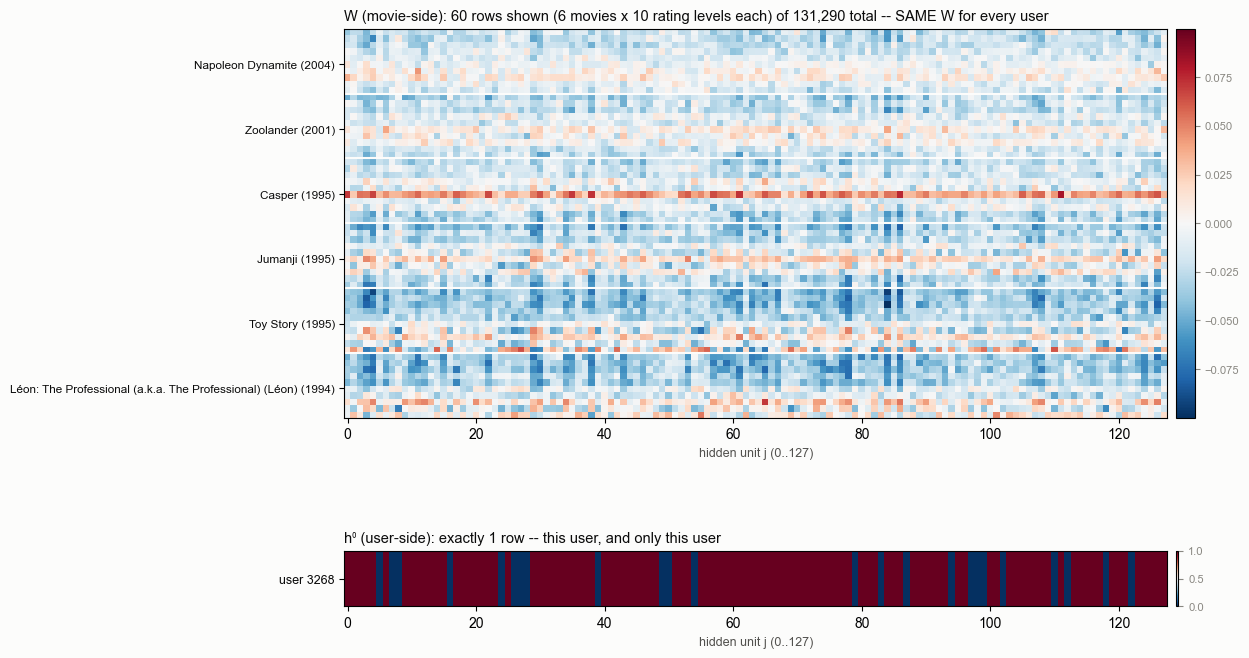

In [29]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# W restricted to the 6 sample movies' 10 rating-level rows each -- real slice of the real W, movie-indexed
W_slice = W_plus.reshape(n_movies, K, n_hidden)[cols_demo[picked_idx]]  # (6 movies, 10 levels, 128 hidden)
W_slice_flat = W_slice.reshape(-1, n_hidden)  # (60, 128)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(11, 7.5), facecolor=SURFACE, gridspec_kw={"height_ratios": [7, 1], "hspace": 0.6})

vmax = float(np.abs(W_slice_flat).max())
im1 = ax1.imshow(W_slice_flat, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax)
ax1.set_yticks([5 + 10 * i for i in range(len(sample_titles))])
ax1.set_yticklabels(sample_titles, fontsize=8.5, color=INK_PRIMARY)
for i in range(1, len(sample_titles)):
    ax1.axhline(i * 10 - 0.5, color=SURFACE, linewidth=1.5)
ax1.set_xlabel("hidden unit j (0..127)", fontsize=9, color=INK_SECONDARY)
ax1.set_title(f"W (movie-side): {W_slice_flat.shape[0]} rows shown (6 movies x 10 rating levels each) of {n_movies*K:,} total -- SAME W for every user", fontsize=10.5, color=INK_PRIMARY, loc="left")
cb1 = plt.colorbar(im1, ax=ax1, pad=0.01, fraction=0.025)
cb1.ax.tick_params(labelsize=8, colors=INK_MUTED)

im2 = ax2.imshow(h0.reshape(1, -1), aspect="auto", cmap="RdBu_r", vmin=0, vmax=1)
ax2.set_yticks([0])
ax2.set_yticklabels([f"user {DEMO_USER_ID}"], fontsize=9, color=INK_PRIMARY)
ax2.set_xlabel("hidden unit j (0..127)", fontsize=9, color=INK_SECONDARY)
ax2.set_title("h⁰ (user-side): exactly 1 row -- this user, and only this user", fontsize=10.5, color=INK_PRIMARY, loc="left")
cb2 = plt.colorbar(im2, ax=ax2, pad=0.01, fraction=0.025)
cb2.ax.tick_params(labelsize=8, colors=INK_MUTED)

plt.savefig(out_dir / f"user{DEMO_USER_ID}_movie_vs_user_side.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()


##### Combined: $v^0 \,@\, W + b = I_j \to \sigma \to h^0$ -- movie-side in, user-side out

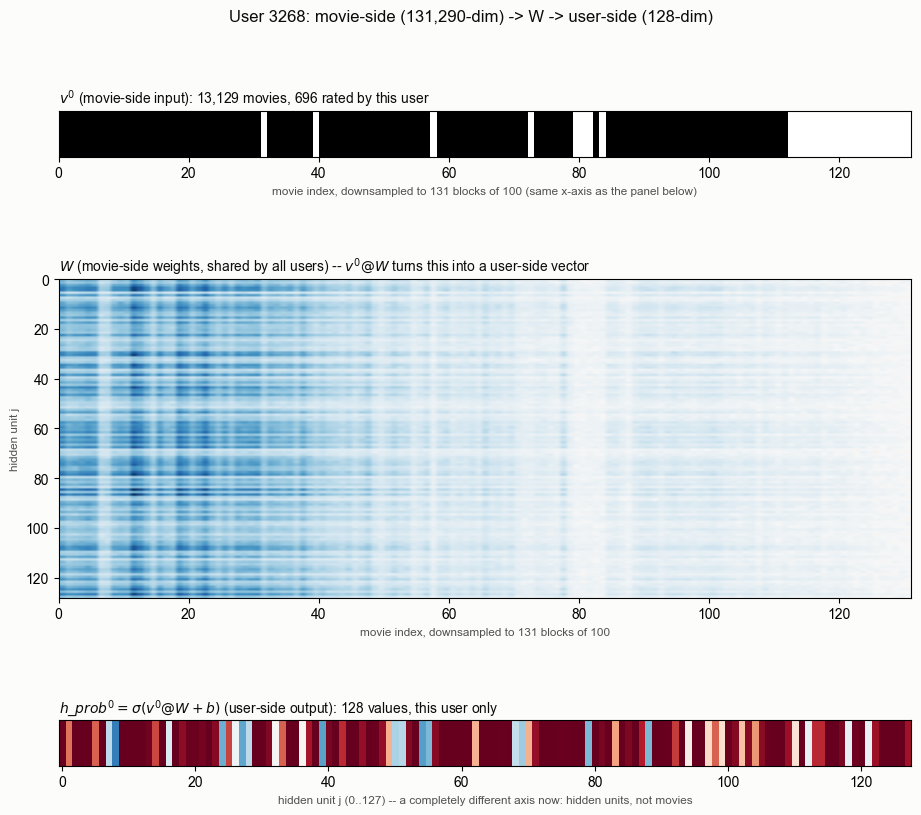

In [30]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
SURFACE = "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

# downsample EVERYTHING to the same movie-block scale, so the three panels stay honestly aligned on the x-axis
block = 100
n_blocks = n_movies // block

v0_by_movie = (v0.reshape(n_movies, K).sum(axis=1) > 0).astype(float)          # (n_movies,) rated=1/unrated=0
v0_downsampled = v0_by_movie[:n_blocks * block].reshape(n_blocks, block).max(axis=1)   # (n_blocks,) -- any rated in this block?

W_mean_over_k = W_plus.reshape(n_movies, K, n_hidden).mean(axis=1)             # (n_movies, 128)
W_downsampled = W_mean_over_k[:n_blocks * block].reshape(n_blocks, block, n_hidden).mean(axis=1)  # (n_blocks, 128)

fig, axes = plt.subplots(3, 1, figsize=(11, 8.5), facecolor=SURFACE, gridspec_kw={"height_ratios": [1, 7, 1], "hspace": 0.9})
ax0, ax1, ax2 = axes

ax0.imshow(v0_downsampled.reshape(1, -1), aspect="auto", cmap="Greys", vmin=0, vmax=1, extent=[0, n_blocks, 0, 1])
ax0.set_yticks([])
ax0.set_xlabel(f"movie index, downsampled to {n_blocks} blocks of {block} (same x-axis as the panel below)", fontsize=8.5, color=INK_SECONDARY)
ax0.set_title(f"$v^0$ (movie-side input): {n_movies:,} movies, {int(v0_by_movie.sum())} rated by this user", fontsize=10, color=INK_PRIMARY, loc="left")

vmax = float(np.abs(W_downsampled).max())
im1 = ax1.imshow(W_downsampled.T, aspect="auto", cmap="RdBu_r", vmin=-vmax, vmax=vmax, extent=[0, n_blocks, n_hidden, 0])
ax1.set_ylabel("hidden unit j", fontsize=8.5, color=INK_SECONDARY)
ax1.set_xlabel(f"movie index, downsampled to {n_blocks} blocks of {block}", fontsize=8.5, color=INK_SECONDARY)
ax1.set_title(r"$W$ (movie-side weights, shared by all users) -- $v^0 @ W$ turns this into a user-side vector", fontsize=10, color=INK_PRIMARY, loc="left")

ax2.imshow(h_prob_0.reshape(1, -1), aspect="auto", cmap="RdBu_r", vmin=0, vmax=1)
ax2.set_yticks([])
ax2.set_xlabel("hidden unit j (0..127) -- a completely different axis now: hidden units, not movies", fontsize=8.5, color=INK_SECONDARY)
ax2.set_title(r"$h\_prob^0=\sigma(v^0 @ W + b)$ (user-side output): 128 values, this user only", fontsize=10, color=INK_PRIMARY, loc="left")

fig.suptitle(f"User {DEMO_USER_ID}: movie-side ({n_movies*K:,}-dim) -> W -> user-side (128-dim)", fontsize=12, color=INK_PRIMARY, y=1.0)
plt.savefig(out_dir / f"user{DEMO_USER_ID}_movie_to_user_combined.png", dpi=150, facecolor=SURFACE, bbox_inches="tight")
plt.show()
